In [ ]:
# DATA LOADING
# ============================================================
# Load all datasets needed for the freight rate prediction task.
#
# train_test.csv:
#   Historical data containing the target variable: posted_rate
#
# validation.csv:
#   Unseen loads for which we must generate predicted_rate
#
# december-chart-inputs (1).csv:
#   Fixed December 2025 scenarios used for the required chart


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the training dataset
train = pd.read_csv("/content/train-test.csv")

# Load the validation dataset
validation = pd.read_csv("/content/validation.csv")

# Load the December prediction dataset
december = pd.read_csv("/content/december-chart-inputs (1).csv")

# Display the dimensions of each dataset
print("DATASET SHAPES")
print("=" * 60)
print("Training dataset:  ", train.shape)
print("Validation dataset:", validation.shape)
print("December dataset:  ", december.shape)

# Confirm that all datasets were loaded successfully
print("\nDATASETS LOADED SUCCESSFULLY.")

DATASET SHAPES
Training dataset:   (48000, 14)
Validation dataset: (12000, 13)
December dataset:   (31, 7)

DATASETS LOADED SUCCESSFULLY.


In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("train-test.csv")

print("Shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())

print("\nFirst 5 rows:")
display(train.head())

Shape: (48000, 14)

Columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

First 5 rows:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [ ]:
print("DATASET INFO")
print("=" * 50)
train.info()

print("\n\nMISSING VALUES")
print("=" * 50)
print(train.isnull().sum())

print("\n\nDUPLICATE ROWS")
print("=" * 50)
print("Number of duplicate rows:", train.duplicated().sum())

print("\n\nTARGET SUMMARY")
print("=" * 50)
print(train["posted_rate"].describe())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


MISSING VALUES
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
d

In [ ]:
print("UNIQUE VALUES")
print("=" * 60)

for column in train.columns:
    print(f"\n{column}")
    print(f"Unique values: {train[column].nunique()}")

    if train[column].nunique() <= 20:
        print(train[column].value_counts())

UNIQUE VALUES

load_id
Unique values: 48000

pickup
Unique values: 64

delivery
Unique values: 64

pickup_lat
Unique values: 64

pickup_lon
Unique values: 63

delivery_lat
Unique values: 64

delivery_lon
Unique values: 63

distance
Unique values: 21204

equipment
Unique values: 3
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

weight
Unique values: 23678

date
Unique values: 304

market_index
Unique values: 32884

quote_signal
Unique values: 37633

posted_rate
Unique values: 45398


In [ ]:
print("DATA TYPES")
print("=" * 60)
print(train.dtypes)

DATA TYPES
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object


In [ ]:
print("CORRELATION WITH POSTED RATE")
print("=" * 60)

numeric_columns = train.select_dtypes(include=np.number).columns

correlation = (
    train[numeric_columns]
    .corr()["posted_rate"]
    .sort_values(ascending=False)
)

print(correlation)

CORRELATION WITH POSTED RATE
posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64


NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


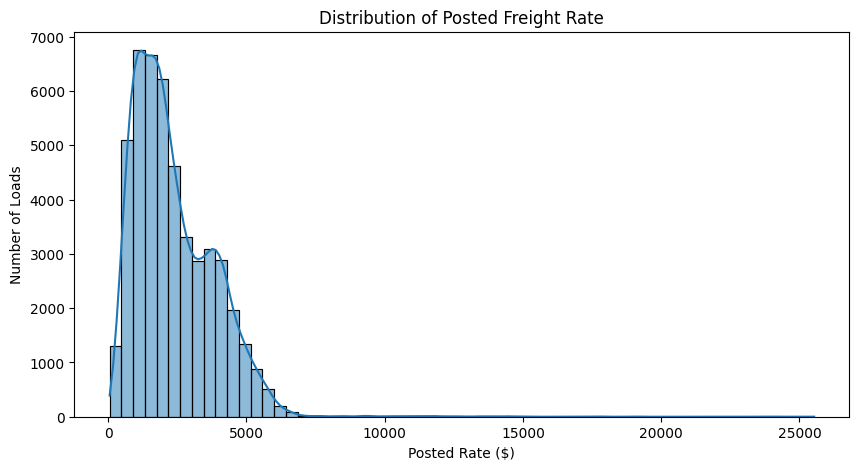

In [ ]:

# 1. NUMERICAL FEATURE SUMMARY

# We first inspect the main numerical variables in the dataset.
# This helps us understand their scale, variation, and possible
# data-quality issues before building any machine learning model.

import matplotlib.pyplot as plt
import seaborn as sns

# Select the numerical columns that are relevant to the analysis.
numeric_cols = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

# Display descriptive statistics such as:
# count, mean, standard deviation, minimum,
# quartiles, and maximum.
print("NUMERICAL FEATURE SUMMARY")
display(train[numeric_cols].describe().T)

# 2. TARGET VARIABLE DISTRIBUTION

# 'posted_rate' is our target variable.
# We visualize its distribution to understand:
# - where most freight rates are concentrated
# - how spread out the rates are
# - whether there are very high or low values
# - whether the target appears skewed

plt.figure(figsize=(10, 5))

sns.histplot(
    train["posted_rate"],
    bins=60,
    kde=True
)

plt.title("Distribution of Posted Freight Rate")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")

plt.show()

In [ ]:
# 3. INVESTIGATE SUSPICIOUS WEIGHT VALUES

# The descriptive statistics show that the minimum
# weight is negative. Since shipment weight should
# normally be positive, we investigate these records
# before deciding how to handle them.

# Find rows where the shipment weight is zero or negative.
invalid_weight_rows = train[train["weight"] <= 0]

print(f"Number of non-positive weight records: {len(invalid_weight_rows)}")

# Display the affected records so we can understand
# whether the values are errors or follow a pattern.
display(
    invalid_weight_rows[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "date",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].head(20)
)

Number of non-positive weight records: 292


,load_id,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,2025-01-03,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,2025-01-04,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,2025-01-05,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,2025-01-06,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,2025-01-07,0.89891,1.81081,1907.83


In [ ]:
# 4. INVESTIGATE WEIGHT DATA QUALITY

# We found negative weight values, which are not physically
# meaningful for a freight shipment.
#
# Before deciding how to clean them, we compare:
# 1. Missing weights
# 2. Negative weights
# 3. Valid positive weights
#
# This helps us understand the scale of the data-quality issue.

missing_weight = train["weight"].isna().sum()
negative_weight = (train["weight"] < 0).sum()
zero_weight = (train["weight"] == 0).sum()
positive_weight = (train["weight"] > 0).sum()

print("WEIGHT DATA QUALITY")
print("=" * 50)

print(f"Missing weights:      {missing_weight:,}")
print(f"Negative weights:     {negative_weight:,}")
print(f"Zero weights:         {zero_weight:,}")
print(f"Positive weights:     {positive_weight:,}")
print(f"Total rows:           {len(train):,}")

# Compare the posted freight rate across the different
# weight-quality groups.
#
# We are not using this to decide the treatment yet.
# We are simply checking whether these groups behave differently.

train["weight_status"] = np.select(
    [
        train["weight"].isna(),
        train["weight"] < 0,
        train["weight"] == 0,
        train["weight"] > 0
    ],
    [
        "Missing",
        "Negative",
        "Zero",
        "Positive"
    ],
    default="Unknown"
)

print("\nAVERAGE POSTED RATE BY WEIGHT STATUS")
display(
    train.groupby("weight_status")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
)

WEIGHT DATA QUALITY
Missing weights:      300
Negative weights:     292
Zero weights:         0
Positive weights:     47,408
Total rows:           48,000

AVERAGE POSTED RATE BY WEIGHT STATUS


,count,mean,median
weight_status,,,
Positive,47408,2374.030869,2031.440
Missing,300,2350.665767,1984.995
Negative,292,2389.786233,1994.960


In [ ]:
# 5. CHECK WEIGHT QUALITY IN OTHER DATASETS

# We identified missing and negative weights in the training data.
# Before deciding on the final preprocessing pipeline, we need to
# check whether the same issue appears in the validation data.
#
# This is important because the same preprocessing must work
# consistently on both training and unseen data.

print("WEIGHT QUALITY CHECK")
print("=" * 50)

# Check the validation dataset
validation_missing = validation["weight"].isna().sum()
validation_negative = (validation["weight"] < 0).sum()
validation_zero = (validation["weight"] == 0).sum()

print("\nVALIDATION DATA")
print(f"Missing weights:  {validation_missing:,}")
print(f"Negative weights: {validation_negative:,}")
print(f"Zero weights:     {validation_zero:,}")
print(f"Total rows:       {len(validation):,}")

# Check the December dataset
december_missing = december["weight"].isna().sum()
december_negative = (december["weight"] < 0).sum()
december_zero = (december["weight"] == 0).sum()

print("\nDECEMBER DATA")
print(f"Missing weights:  {december_missing:,}")
print(f"Negative weights: {december_negative:,}")
print(f"Zero weights:     {december_zero:,}")
print(f"Total rows:       {len(december):,}")

WEIGHT QUALITY CHECK

VALIDATION DATA
Missing weights:  165
Negative weights: 145
Zero weights:     0
Total rows:       12,000

DECEMBER DATA
Missing weights:  0
Negative weights: 0
Zero weights:     0
Total rows:       31


In [ ]:

# INVALID WEIGHT INSPECTION

# We inspect invalid weight values before deciding how to
# preprocess them. We do not remove any records at this stage.

invalid_weight_train = train[
    train["weight"].isna() | (train["weight"] < 0)
]

print("INVALID WEIGHTS IN TRAINING DATA")
print("=" * 60)
print("Number of invalid records:", len(invalid_weight_train))

print("\nWeight statistics for invalid records:")
print(invalid_weight_train["weight"].describe())

print("\nSample of invalid weight records:")
display(
    invalid_weight_train[
        ["load_id", "pickup", "delivery", "distance",
         "equipment", "weight", "date", "posted_rate"]
    ].head(20)
)

INVALID WEIGHTS IN TRAINING DATA
Number of invalid records: 592

Weight statistics for invalid records:
count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

Sample of invalid weight records:


,load_id,pickup,delivery,distance,equipment,weight,date,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,2025-01-01,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,2025-01-02,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,2025-01-02,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,2025-01-02,2836.00
323,TR-000324,Richmond,San Francisco,2848.8,Reefer,NaN,2025-01-03,5430.07
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,2025-01-03,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,2025-01-03,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,2025-01-04,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,2025-01-05,1264.33
648,TR-000649,Tulsa,Mobile,467.0,Reefer,NaN,2025-01-05,1178.03


In [ ]:
# ============================================================
# INVALID WEIGHT VS VALID WEIGHT
# ============================================================
# Compare the main numerical variables between valid and
# invalid weight records. This helps us decide how to treat
# the corrupted weight values during preprocessing.

train_check = train.copy()

# Create a simple weight-quality label
train_check["weight_status"] = np.where(
    train_check["weight"].isna(),
    "Missing",
    np.where(
        train_check["weight"] < 0,
        "Negative",
        "Positive"
    )
)

# Compare the main numerical variables
comparison = (
    train_check
    .groupby("weight_status")[
        ["distance", "market_index", "quote_signal", "posted_rate"]
    ]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("COMPARISON BY WEIGHT STATUS")
print("=" * 70)

display(comparison)

COMPARISON BY WEIGHT STATUS


distance                  market_index               \
                 count     mean  median        count  mean median   
weight_status                                                       
Missing            300  1145.48  944.40          299  1.06   1.03   
Negative           292  1120.92  930.45          289  1.10   1.07   
Positive         47408  1135.89  953.40        47038  1.08   1.06   

              quote_signal              posted_rate                    
                     count  mean median       count     mean   median  
weight_status                                                          
Missing                300  2.07   2.07         300  2350.67  1985.00  
Negative               292  2.04   2.03         292  2389.79  1994.96  
Positive             47408  2.06   2.06       47408  2374.03  2031.44

In [ ]:
# Compare equipment types across the three weight-quality groups

equipment_comparison = pd.crosstab(
    train_check["equipment"],
    train_check["weight_status"],
    normalize="columns"
).round(3)

print("EQUIPMENT DISTRIBUTION BY WEIGHT STATUS")
print("=" * 70)

display(equipment_comparison)

EQUIPMENT DISTRIBUTION BY WEIGHT STATUS


weight_status,Missing,Negative,Positive
equipment,,,
Dry Van,0.583,0.531,0.567
Flatbed,0.183,0.240,0.182
Reefer,0.233,0.229,0.251


In [ ]:
# ============================================================
# WEIGHT CLEANING
# ============================================================
# Negative weights are not physically meaningful for freight
# loads, so they are treated as missing values.
#
# We keep the affected rows because the other features still
# contain useful information and the assessment requires
# predictions for every validation load.

train_clean = train.copy()
validation_clean = validation.copy()
december_clean = december.copy()

# Convert negative weights to missing values
train_clean.loc[train_clean["weight"] < 0, "weight"] = np.nan
validation_clean.loc[validation_clean["weight"] < 0, "weight"] = np.nan
december_clean.loc[december_clean["weight"] < 0, "weight"] = np.nan

print("WEIGHT CLEANING SUMMARY")
print("=" * 60)

print("\nTraining:")
print("Missing weights after cleaning:",
      train_clean["weight"].isna().sum())

print("\nValidation:")
print("Missing weights after cleaning:",
      validation_clean["weight"].isna().sum())

print("\nDecember:")
print("Missing weights after cleaning:",
      december_clean["weight"].isna().sum())

WEIGHT CLEANING SUMMARY

Training:
Missing weights after cleaning: 592

Validation:
Missing weights after cleaning: 310

December:
Missing weights after cleaning: 0


In [ ]:
# ============================================================
# DATE FEATURE INSPECTION
# ============================================================
# Convert the date column to datetime so we can examine the
# temporal structure of the dataset.

train_clean["date"] = pd.to_datetime(train_clean["date"])
validation_clean["date"] = pd.to_datetime(validation_clean["date"])
december_clean["date"] = pd.to_datetime(december_clean["date"])

print("DATE RANGE")
print("=" * 60)

print("Training:")
print("Start:", train_clean["date"].min())
print("End:  ", train_clean["date"].max())

print("\nValidation:")
print("Start:", validation_clean["date"].min())
print("End:  ", validation_clean["date"].max())

print("\nDecember:")
print("Start:", december_clean["date"].min())
print("End:  ", december_clean["date"].max())

# Check the number of training records per day
daily_counts = train_clean.groupby("date").size()

print("\nTRAINING RECORDS PER DAY")
print("=" * 60)
print("Minimum:", daily_counts.min())
print("Maximum:", daily_counts.max())
print("Average:", round(daily_counts.mean(), 2))

display(daily_counts.head(10))

DATE RANGE
Training:
Start: 2025-01-01 00:00:00
End:   2025-10-31 00:00:00

Validation:
Start: 2025-11-01 00:00:00
End:   2025-12-31 00:00:00

December:
Start: 2025-12-01 00:00:00
End:   2025-12-31 00:00:00

TRAINING RECORDS PER DAY
Minimum: 115
Maximum: 198
Average: 157.89


,0
date,
2025-01-01,145
2025-01-02,168
2025-01-03,156
2025-01-04,156
2025-01-05,154
2025-01-06,168
2025-01-07,161
2025-01-08,189
2025-01-09,148


In [ ]:
# ============================================================
# TIME-BASED TRAIN / VALIDATION SPLIT
# ============================================================
# We use a chronological split instead of a random split.
# This better represents the real prediction task:
# training on earlier loads and validating on later loads.
# ============================================================

# Make sure the date column is stored as datetime
train["date"] = pd.to_datetime(train["date"])

# Sort the data chronologically
train = train.sort_values("date").reset_index(drop=True)

# Find the date that separates the first 80% from the last 20%
split_index = int(len(train) * 0.80)

# Create chronological training and validation sets
model_train = train.iloc[:split_index].copy()
model_valid = train.iloc[split_index:].copy()

print("TIME-BASED DATA SPLIT")
print("=" * 55)

print("\nModel training period:")
print("Start:", model_train["date"].min())
print("End:  ", model_train["date"].max())
print("Rows:", f"{len(model_train):,}")

print("\nModel validation period:")
print("Start:", model_valid["date"].min())
print("End:  ", model_valid["date"].max())
print("Rows:", f"{len(model_valid):,}")

print("\nValidation percentage:",
      f"{len(model_valid) / len(train) * 100:.1f}%")

TIME-BASED DATA SPLIT

Model training period:
Start: 2025-01-01 00:00:00
End:   2025-08-31 00:00:00
Rows: 38,400

Model validation period:
Start: 2025-08-31 00:00:00
End:   2025-10-31 00:00:00
Rows: 9,600

Validation percentage: 20.0%


In [ ]:
# ============================================================
# STRICT DATE-BASED TRAIN / VALIDATION SPLIT
# ============================================================
# We split by calendar date so that no date appears in both
# the training and validation sets.
# ============================================================

split_date = pd.Timestamp("2025-09-01")

model_train = train[train["date"] < split_date].copy()
model_valid = train[train["date"] >= split_date].copy()

print("STRICT TIME-BASED DATA SPLIT")
print("=" * 55)

print("\nModel training period:")
print("Start:", model_train["date"].min())
print("End:  ", model_train["date"].max())
print("Rows:", f"{len(model_train):,}")

print("\nModel validation period:")
print("Start:", model_valid["date"].min())
print("End:  ", model_valid["date"].max())
print("Rows:", f"{len(model_valid):,}")

print("\nValidation percentage:",
      f"{len(model_valid) / len(train) * 100:.1f}%")

# Confirm that the two periods do not overlap
overlap = set(model_train["date"]).intersection(set(model_valid["date"]))

print("\nDate overlap:", len(overlap))

STRICT TIME-BASED DATA SPLIT

Model training period:
Start: 2025-01-01 00:00:00
End:   2025-08-31 00:00:00
Rows: 38,477

Model validation period:
Start: 2025-09-01 00:00:00
End:   2025-10-31 00:00:00
Rows: 9,523

Validation percentage: 19.8%

Date overlap: 0


In [ ]:
# ============================================================
# CLEAN WEIGHT VALUES
# ============================================================
# A load weight cannot be negative.
# We therefore treat negative weights as missing values.
# Missing values will be handled during preprocessing.
# ============================================================

# Create copies so the original datasets remain unchanged
model_train = model_train.copy()
model_valid = model_valid.copy()
december = december.copy()

# Convert negative weights to NaN
model_train.loc[model_train["weight"] < 0, "weight"] = np.nan
model_valid.loc[model_valid["weight"] < 0, "weight"] = np.nan
december.loc[december["weight"] < 0, "weight"] = np.nan

print("WEIGHT CLEANING")
print("=" * 55)

print("\nTraining:")
print("Missing weights:", model_train["weight"].isna().sum())

print("\nValidation:")
print("Missing weights:", model_valid["weight"].isna().sum())

print("\nDecember:")
print("Missing weights:", december["weight"].isna().sum())

WEIGHT CLEANING

Training:
Missing weights: 468

Validation:
Missing weights: 124

December:
Missing weights: 0


In [ ]:
# ============================================================
# CHECK MISSING VALUES IN NUMERICAL FEATURES
# ============================================================
# Training and validation contain the full set of model
# features. The December file has a smaller set of fixed
# columns, so we check only the columns available in each file.
# ============================================================

# Numerical features available in the training/validation data
model_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal"
]

# Numerical columns available in the December prediction file
december_features = [
    "distance",
    "weight"
]

print("MISSING VALUES AFTER DATA SPLIT AND WEIGHT CLEANING")
print("=" * 60)

print("\nTraining data:")
print(model_train[model_features].isna().sum())

print("\nValidation data:")
print(model_valid[model_features].isna().sum())

print("\nDecember data:")
print(december[december_features].isna().sum())

MISSING VALUES AFTER DATA SPLIT AND WEIGHT CLEANING

Training data:
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
weight          468
market_index    301
quote_signal      0
dtype: int64

Validation data:
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
weight          124
market_index     73
quote_signal      0
dtype: int64

December data:
distance    0
weight      0
dtype: int64


In [ ]:
# ============================================================
# HANDLE MISSING NUMERICAL VALUES
# ============================================================
# We calculate imputation values using ONLY the model-training
# data. The same values are then applied to validation data.
# This prevents information leakage from the validation period.
# ============================================================

# Calculate medians from training data only
weight_median = model_train["weight"].median()
market_index_median = model_train["market_index"].median()

print("IMPUTATION VALUES FROM TRAINING DATA")
print("=" * 55)
print(f"Weight median: {weight_median:.2f}")
print(f"Market index median: {market_index_median:.4f}")

# Fill missing values in the training data
model_train["weight"] = model_train["weight"].fillna(weight_median)
model_train["market_index"] = model_train["market_index"].fillna(
    market_index_median
)

# Apply the SAME training medians to validation data
model_valid["weight"] = model_valid["weight"].fillna(weight_median)
model_valid["market_index"] = model_valid["market_index"].fillna(
    market_index_median
)

print("\nMISSING VALUES AFTER IMPUTATION")
print("=" * 55)

print("\nTraining:")
print(model_train[["weight", "market_index"]].isna().sum())

print("\nValidation:")
print(model_valid[["weight", "market_index"]].isna().sum())

IMPUTATION VALUES FROM TRAINING DATA
Weight median: 31467.00
Market index median: 1.1200

MISSING VALUES AFTER IMPUTATION

Training:
weight          0
market_index    0
dtype: int64

Validation:
weight          0
market_index    0
dtype: int64


In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Convert the date into separate calendar features and create
# a route identifier from pickup and delivery locations.
# ============================================================

def create_features(data):
    """Create model-ready features from the raw dataset."""

    data = data.copy()

    # Make sure date is stored as datetime
    data["date"] = pd.to_datetime(data["date"])

    # Calendar features
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["day_of_year"] = data["date"].dt.dayofyear
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)

    # Route identifier
    data["route"] = data["pickup"] + " -> " + data["delivery"]

    return data


# Apply the same feature engineering to both datasets
model_train = create_features(model_train)
model_valid = create_features(model_valid)

print("FEATURE ENGINEERING")
print("=" * 55)

print("\nNew features:")
print([
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "route"
])

print("\nTraining shape:", model_train.shape)
print("Validation shape:", model_valid.shape)

print("\nSample of engineered features:")
display(
    model_train[
        [
            "date",
            "pickup",
            "delivery",
            "route",
            "month",
            "day_of_week",
            "day_of_year"
        ]
    ].head()
)

FEATURE ENGINEERING

New features:
['year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route']

Training shape: (38477, 21)
Validation shape: (9523, 21)

Sample of engineered features:


,date,pickup,delivery,route,month,day_of_week,day_of_year
0,2025-01-01,Richmond,Baltimore,Richmond -> Baltimore,1,2,1
1,2025-01-01,Montgomery,Milwaukee,Montgomery -> Milwaukee,1,2,1
2,2025-01-01,Hartford,Madison,Hartford -> Madison,1,2,1
3,2025-01-01,Hartford,Charleston,Hartford -> Charleston,1,2,1
4,2025-01-01,Los Angeles,Reno,Los Angeles -> Reno,1,2,1


In [ ]:
# Check the columns available in the external validation dataset.
# This dataset is used later for the final predictions, so it does not
# contain the target variable posted_rate.

print("Validation dataset columns:")
print(validation.columns.tolist())

print("\nValidation shape:")
print(validation.shape)

Validation dataset columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

Validation shape:
(12000, 13)


In [ ]:
# Create a time-based validation split from the labeled training data.
# The model will learn from earlier dates and be evaluated on later dates.
# This better reflects the real forecasting situation.

train_model = train[
    train["date"] < "2025-09-01"
].copy()

model_validation = train[
    train["date"] >= "2025-09-01"
].copy()

print("TIME-BASED MODEL SPLIT")
print("=" * 60)

print("\nModel training data:")
print("Rows:", len(train_model))
print("Start:", train_model["date"].min())
print("End:", train_model["date"].max())

print("\nModel validation data:")
print("Rows:", len(model_validation))
print("Start:", model_validation["date"].min())
print("End:", model_validation["date"].max())

print("\nValidation percentage:",
      round(len(model_validation) / len(train) * 100, 1), "%")

TIME-BASED MODEL SPLIT

Model training data:
Rows: 38477
Start: 2025-01-01 00:00:00
End: 2025-08-31 00:00:00

Model validation data:
Rows: 9523
Start: 2025-09-01 00:00:00
End: 2025-10-31 00:00:00

Validation percentage: 19.8 %


In [ ]:
# Create one feature-engineering function so that the same transformations
# are applied consistently to training, validation, and December data.

def create_features(df):
    data = df.copy()

    # Convert date to datetime so we can extract calendar information.
    data["date"] = pd.to_datetime(data["date"])

    # Calendar-based features.
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["day_of_year"] = data["date"].dt.dayofyear
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)

    # Represent the origin-destination combination as a route feature.
    data["route"] = data["pickup"] + " -> " + data["delivery"]

    return data


# Apply the same feature engineering to each dataset.
train_model_features = create_features(train_model)
validation_features = create_features(model_validation)
assessment_features = create_features(validation)
december_features = create_features(december)

print("FEATURE ENGINEERING")
print("=" * 60)

print("\nTraining:", train_model_features.shape)
print("Internal validation:", validation_features.shape)
print("Assessment validation:", assessment_features.shape)
print("December:", december_features.shape)

print("\nNew features:")
print([
    "year",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "route"
])

FEATURE ENGINEERING

Training: (38477, 21)
Internal validation: (9523, 21)
Assessment validation: (12000, 20)
December: (31, 14)

New features:
['year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route']


In [ ]:
# Prepare the model inputs.
# CatBoost can work directly with categorical features, so we keep
# pickup, delivery, equipment, and route as categorical variables.

target = "posted_rate"

# Columns that should not be used as model predictors.
drop_columns = ["load_id", "date", target]

X_train_model = train_model_features.drop(columns=drop_columns)
y_train_model = train_model_features[target]

X_val_model = validation_features.drop(columns=drop_columns)
y_val_model = validation_features[target]

# Identify categorical columns.
categorical_columns = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

print("MODEL PREPARATION")
print("=" * 60)

print("\nTraining features:", X_train_model.shape)
print("Validation features:", X_val_model.shape)

print("\nCategorical features:")
print(categorical_columns)

print("\nNumerical features:")
print([
    column for column in X_train_model.columns
    if column not in categorical_columns
])

MODEL PREPARATION

Training features: (38477, 18)
Validation features: (9523, 18)

Categorical features:
['pickup', 'delivery', 'equipment', 'route']

Numerical features:
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year']


In [ ]:
# Install CatBoost for the modeling stage
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
# Train the first CatBoost baseline model.
# CatBoost is suitable here because it can handle categorical
# features directly without one-hot encoding.

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Convert categorical columns to strings.
# This ensures CatBoost treats them correctly.
for col in categorical_columns:
    X_train_model[col] = X_train_model[col].astype(str)
    X_val_model[col] = X_val_model[col].astype(str)

# Find categorical column positions.
cat_feature_indices = [
    X_train_model.columns.get_loc(col)
    for col in categorical_columns
]

# Create the baseline CatBoost model.
catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

print("TRAINING CATBOOST MODEL")
print("=" * 60)

# Train using the time-based validation set for evaluation.
catboost_model.fit(
    X_train_model,
    y_train_model,
    cat_features=cat_feature_indices,
    eval_set=(X_val_model, y_val_model),
    early_stopping_rounds=100
)

print("\nModel training completed.")
print("Best iteration:", catboost_model.get_best_iteration())

TRAINING CATBOOST MODEL
0:	learn: 1420.2585090	test: 1470.5040711	best: 1470.5040711 (0)	total: 180ms	remaining: 2m 59s
100:	learn: 573.9858478	test: 633.5591104	best: 633.5591104 (100)	total: 7.41s	remaining: 1m 5s
200:	learn: 562.3957664	test: 632.8176230	best: 632.7272467 (154)	total: 12.7s	remaining: 50.4s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 632.7272467
bestIteration = 154

Shrink model to first 155 iterations.

Model training completed.
Best iteration: 154


In [ ]:
# Evaluate CatBoost baseline on the time-based validation set.

y_val_pred = catboost_model.predict(X_val_model)

mae = mean_absolute_error(y_val_model, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val_model, y_val_pred))
r2 = r2_score(y_val_model, y_val_pred)

print("CATBOOST BASELINE VALIDATION RESULTS")
print("=" * 60)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

CATBOOST BASELINE VALIDATION RESULTS
MAE  : 111.62
RMSE : 632.73
R²   : 0.8281


In [ ]:
# Analyze validation prediction errors.
# This helps us understand where the baseline model performs poorly.

validation_results = validation_features[
    ["load_id", "pickup", "delivery", "equipment", "distance", "weight", "date", "posted_rate"]
].copy()

validation_results["predicted_rate"] = y_val_pred

validation_results["error"] = (
    validation_results["posted_rate"]
    - validation_results["predicted_rate"]
)

validation_results["absolute_error"] = (
    validation_results["error"].abs()
)

validation_results["percentage_error"] = (
    validation_results["absolute_error"]
    / validation_results["posted_rate"].replace(0, np.nan)
) * 100

print("PREDICTION ERROR ANALYSIS")
print("=" * 60)

print("\nError statistics:")
print(validation_results["error"].describe())

print("\nAbsolute error statistics:")
print(validation_results["absolute_error"].describe())

print("\nMean absolute percentage error:")
print(
    validation_results["percentage_error"].mean()
)

print("\nLargest prediction errors:")
display(
    validation_results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

PREDICTION ERROR ANALYSIS

Error statistics:
count     9523.000000
mean        43.731933
std        631.247286
min      -3778.189969
25%        -31.638721
50%          6.733850
75%         45.811926
max      16246.714790
Name: error, dtype: float64

Absolute error statistics:
count     9523.000000
mean       111.618007
std        622.837002
min          0.007540
25%         17.630882
50%         38.903403
75%         74.081139
max      16246.714790
Name: absolute_error, dtype: float64

Mean absolute percentage error:
5.408697753177871

Largest prediction errors:


,load_id,pickup,delivery,equipment,distance,weight,date,posted_rate,predicted_rate,error,absolute_error,percentage_error
40156,TR-040097,Baltimore,Oklahoma City,Reefer,1760.3,29521.0,2025-09-11,20132.37,3885.655210,16246.714790,16246.714790,80.699465
40071,TR-040172,Montgomery,Fresno,Dry Van,2283.4,32447.0,2025-09-11,20361.89,4393.483017,15968.406983,15968.406983,78.423010
43605,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,30760.0,2025-10-03,17514.11,3631.463438,13882.646562,13882.646562,79.265498
46279,TR-046214,Columbia,Tucson,Flatbed,2023.4,34710.0,2025-10-20,17893.17,4226.912891,13666.257109,13666.257109,76.376948
47204,TR-047299,Boston,Bakersfield,Reefer,2979.1,30585.0,2025-10-27,19110.30,5920.739308,13189.560692,13189.560692,69.018072
40220,TR-040323,Montgomery,El Paso,Dry Van,1639.9,38363.0,2025-09-12,14949.25,3288.996864,11660.253136,11660.253136,77.998917
46608,TR-046517,Toledo,Albuquerque,Reefer,1684.3,31536.0,2025-10-22,14784.38,3604.209157,11180.170843,11180.170843,75.621506
42941,TR-042882,San Antonio,Detroit,Dry Van,1460.5,43567.0,2025-09-29,13503.63,2986.324943,10517.305057,10517.305057,77.885021
42247,TR-042150,Grand Rapids,Lubbock,Dry Van,1415.5,35333.0,2025-09-24,13026.22,2886.691047,10139.528953,10139.528953,77.839381
46444,TR-046367,Bakersfield,Columbia,Dry Van,2251.9,40729.0,2025-10-21,14403.14,4339.329834,10063.810166,10063.810166,69.872335


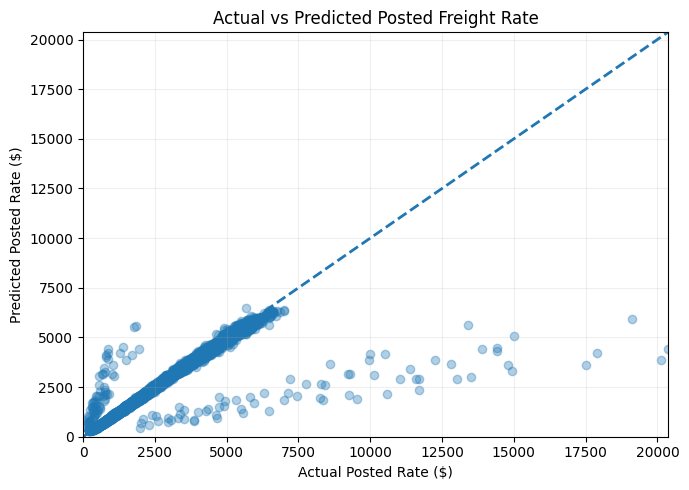

In [ ]:
# Visualize actual vs predicted posted rates.
# This helps identify systematic prediction errors and extreme outliers.

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    validation_results["posted_rate"],
    validation_results["predicted_rate"],
    alpha=0.35
)

# Perfect-prediction reference line
max_value = max(
    validation_results["posted_rate"].max(),
    validation_results["predicted_rate"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Posted Rate ($)")
plt.ylabel("Predicted Posted Rate ($)")
plt.title("Actual vs Predicted Posted Freight Rate")

plt.xlim(0, max_value)
plt.ylim(0, max_value)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# Examine prediction error across different posted-rate ranges.

validation_results["rate_group"] = pd.cut(
    validation_results["posted_rate"],
    bins=[0, 1000, 2000, 3000, 5000, 10000, np.inf],
    labels=[
        "0–1K",
        "1K–2K",
        "2K–3K",
        "3K–5K",
        "5K–10K",
        "10K+"
    ],
    include_lowest=True
)

error_by_group = (
    validation_results
    .groupby("rate_group", observed=True)
    .agg(
        count=("posted_rate", "size"),
        mean_actual=("posted_rate", "mean"),
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median")
    )
)

print("ERROR BY POSTED-RATE RANGE")
print("=" * 70)

display(error_by_group)

ERROR BY POSTED-RATE RANGE


,count,mean_actual,mean_absolute_error,median_absolute_error
rate_group,,,,
0–1K,1545,697.316311,81.454633,23.802635
1K–2K,3077,1482.622294,45.622898,30.488680
2K–3K,2077,2430.546326,56.412718,42.672288
3K–5K,2316,3899.394167,100.933646,63.999154
5K–10K,484,5637.596074,412.958522,141.579702
10K+,24,14003.431250,10246.073097,9704.777115


Number of feature names: 18
Number of importance values: 18

CATBOOST FEATURE IMPORTANCE
     feature  importance
    distance   86.538951
   equipment    4.459075
      weight    1.608618
market_index    1.240495
week_of_year    0.819966
    delivery    0.690393
      pickup    0.665242
quote_signal    0.573499
 day_of_year    0.536568
delivery_lat    0.533423
  pickup_lat    0.506925
       month    0.483995
delivery_lon    0.428333
  pickup_lon    0.268768
         day    0.260294
 day_of_week    0.194628
       route    0.190826
        year    0.000000


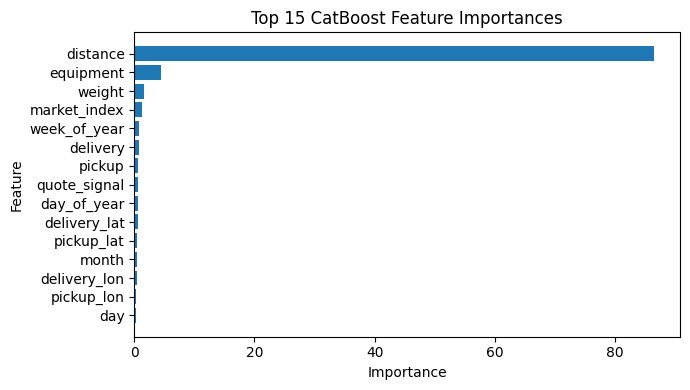

In [ ]:
# ============================================================
# CATBOOST FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names directly from the trained CatBoost model
feature_names = catboost_model.feature_names_
feature_importance = catboost_model.get_feature_importance()

# Check lengths
print("Number of feature names:", len(feature_names))
print("Number of importance values:", len(feature_importance))

# Create DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
})

# Sort from most to least important
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("\nCATBOOST FEATURE IMPORTANCE")
print("=" * 60)
print(importance_df.to_string(index=False))

# ============================================================
# PLOT TOP 15 FEATURES
# ============================================================

top_n = min(15, len(importance_df))

top_features = (
    importance_df
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(7, 4))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 CatBoost Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Check the variables currently available

print("Variables related to validation/prediction:")

for name in sorted(dir()):
    if any(x in name.lower() for x in ["valid", "pred", "target", "catboost"]):
        print(name)

Variables related to validation/prediction:
CatBoostRegressor
catboost_model
invalid_weight_rows
invalid_weight_train
model_valid
model_validation
target
validation
validation_clean
validation_features
validation_missing
validation_negative
validation_results
validation_zero
y_val_pred


RESIDUAL ANALYSIS

Error statistics:
count     9523.000000
mean        43.731933
std        631.247286
min      -3778.189969
25%        -31.638721
50%          6.733850
75%         45.811926
max      16246.714790
Name: error, dtype: float64

Absolute error statistics:
count     9523.000000
mean       111.618007
std        622.837002
min          0.007540
25%         17.630882
50%         38.903403
75%         74.081139
max      16246.714790
Name: absolute_error, dtype: float64

ERROR BY DISTANCE RANGE
                count  mean_absolute_error  median_absolute_error
distance_group                                                   
0-500            2090            54.837776              24.775964
500-1K           2972            74.296443              32.871148
1K-1.5K          1760           117.719968              43.354171
1.5K-2K          1167           179.923102              63.693619
2K-3K            1402           195.892095              80.430177
3K+               132          

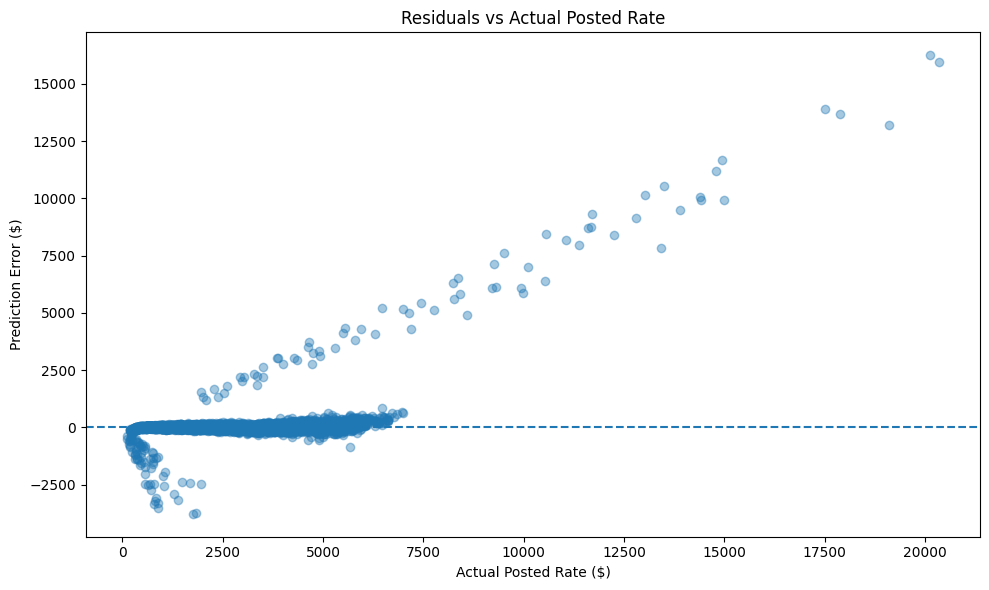

In [ ]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Actual target values
y_val_actual = model_validation[target].values

# Create residual dataframe
residual_df = pd.DataFrame({
    "actual": y_val_actual,
    "predicted": y_val_pred
})

# Calculate errors
residual_df["error"] = (
    residual_df["actual"] - residual_df["predicted"]
)

residual_df["absolute_error"] = (
    residual_df["error"].abs()
)

# Add important features
residual_df["distance"] = validation_features["distance"].values
residual_df["weight"] = validation_features["weight"].values

# ============================================================
# ERROR STATISTICS
# ============================================================

print("RESIDUAL ANALYSIS")
print("=" * 60)

print("\nError statistics:")
print(residual_df["error"].describe())

print("\nAbsolute error statistics:")
print(residual_df["absolute_error"].describe())

# ============================================================
# ERROR BY DISTANCE RANGE
# ============================================================

residual_df["distance_group"] = pd.cut(
    residual_df["distance"],
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=[
        "0-500",
        "500-1K",
        "1K-1.5K",
        "1.5K-2K",
        "2K-3K",
        "3K+"
    ]
)

distance_error = residual_df.groupby(
    "distance_group",
    observed=True
).agg(
    count=("absolute_error", "size"),
    mean_absolute_error=("absolute_error", "mean"),
    median_absolute_error=("absolute_error", "median")
)

print("\nERROR BY DISTANCE RANGE")
print("=" * 60)
print(distance_error)

# ============================================================
# RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    residual_df["actual"],
    residual_df["error"],
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Actual Posted Rate ($)")
plt.ylabel("Prediction Error ($)")
plt.title("Residuals vs Actual Posted Rate")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# HIGH-RATE ERROR ANALYSIS
# ============================================================

# Add actual and predicted rate information
high_rate_analysis = residual_df.copy()

# Calculate percentage error
high_rate_analysis["percentage_error"] = (
    high_rate_analysis["absolute_error"]
    / high_rate_analysis["actual"].abs()
) * 100

# Select high actual-rate records
high_rate = high_rate_analysis[
    high_rate_analysis["actual"] >= 10000
].copy()

print("HIGH-RATE RECORDS (ACTUAL RATE >= $10,000)")
print("=" * 70)

print(f"Number of records: {len(high_rate)}")

if len(high_rate) > 0:

    print("\nError statistics:")
    print(high_rate[
        ["actual", "predicted", "error", "absolute_error", "percentage_error"]
    ].describe())

    print("\nSample of high-rate records:")

    # Show the largest errors
    largest_high_rate_errors = high_rate.sort_values(
        "absolute_error",
        ascending=False
    ).head(20)

    display(largest_high_rate_errors)

else:
    print("No records with actual rate >= $10,000.")

HIGH-RATE RECORDS (ACTUAL RATE >= $10,000)
Number of records: 24

Error statistics:
             actual    predicted         error  absolute_error  \
count     24.000000    24.000000     24.000000       24.000000   
mean   14003.431250  3757.358153  10246.073097    10246.073097   
std     3032.876568   951.905188   2642.390744     2642.390744   
min    10119.160000  2140.865393   6373.170899     6373.170899   
25%    11662.595000  2970.551157   8417.836265     8417.836265   
50%    13462.110000  3642.037042   9704.777115     9704.777115   
75%    14962.825000  4352.868130  11300.191416    11300.191416   
max    20361.890000  5920.739308  16246.714790    16246.714790   

       percentage_error  
count         24.000000  
mean          72.809196  
std            6.080385  
min           58.179550  
25%           68.981247  
50%           74.390420  
75%           77.913495  
max           80.699465  

Sample of high-rate records:


,actual,predicted,error,absolute_error,distance,weight,distance_group,percentage_error
1679,20132.37,3885.655210,16246.714790,16246.714790,1760.3,29521.0,1.5K-2K,80.699465
1594,20361.89,4393.483017,15968.406983,15968.406983,2283.4,32447.0,2K-3K,78.423010
5128,17514.11,3631.463438,13882.646562,13882.646562,1893.0,30760.0,1.5K-2K,79.265498
7802,17893.17,4226.912891,13666.257109,13666.257109,2023.4,34710.0,2K-3K,76.376948
8727,19110.30,5920.739308,13189.560692,13189.560692,2979.1,30585.0,2K-3K,69.018072
1743,14949.25,3288.996864,11660.253136,11660.253136,1639.9,38363.0,1.5K-2K,77.998917
8131,14784.38,3604.209157,11180.170843,11180.170843,1684.3,31536.0,1.5K-2K,75.621506
4464,13503.63,2986.324943,10517.305057,10517.305057,1460.5,43567.0,1K-1.5K,77.885021
3770,13026.22,2886.691047,10139.528953,10139.528953,1415.5,35333.0,1K-1.5K,77.839381
7967,14403.14,4339.329834,10063.810166,10063.810166,2251.9,40729.0,2K-3K,69.872335


In [ ]:
# ============================================================
# HIGH-RATE PATTERN ANALYSIS
# ============================================================

print("=" * 70)
print("HIGH-RATE PATTERN ANALYSIS")
print("=" * 70)

# Select high-rate records
high_rate = validation_results[
    validation_results["posted_rate"] >= 10000
].copy()

print(f"\nNumber of high-rate records: {len(high_rate)}")

# ------------------------------------------------------------
# Create distance groups directly
# ------------------------------------------------------------

bins = [0, 500, 1000, 1500, 2000, 3000, float("inf")]
labels = ["0-500", "500-1K", "1K-1.5K", "1.5K-2K", "2K-3K", "3K+"]

high_rate["distance_group"] = pd.cut(
    high_rate["distance"],
    bins=bins,
    labels=labels,
    right=False
)

# ------------------------------------------------------------
# Feature statistics
# ------------------------------------------------------------

print("\nHigh-rate feature statistics:")

print(
    high_rate[
        ["posted_rate", "predicted_rate", "distance", "weight"]
    ].describe().round(2)
)

# ------------------------------------------------------------
# Average values
# ------------------------------------------------------------

print("\nHigh-rate averages:")

print(f"Actual rate:    ${high_rate['posted_rate'].mean():,.2f}")
print(f"Predicted rate: ${high_rate['predicted_rate'].mean():,.2f}")
print(f"Distance:       {high_rate['distance'].mean():,.2f}")
print(f"Weight:         {high_rate['weight'].mean():,.2f}")

# ------------------------------------------------------------
# Equipment distribution
# ------------------------------------------------------------

print("\nEquipment distribution among high-rate records:")
print(high_rate["equipment"].value_counts())

# ------------------------------------------------------------
# Distance groups
# ------------------------------------------------------------

print("\nDistance groups among high-rate records:")
print(high_rate["distance_group"].value_counts().sort_index())

# ------------------------------------------------------------
# Show records
# ------------------------------------------------------------

print("\nHigh-rate records:")

display(
    high_rate[
        [
            "load_id",
            "pickup",
            "delivery",
            "equipment",
            "distance",
            "weight",
            "posted_rate",
            "predicted_rate",
            "error",
            "absolute_error",
            "percentage_error",
            "distance_group"
        ]
    ].sort_values(
        "posted_rate",
        ascending=False
    )
)

HIGH-RATE PATTERN ANALYSIS

Number of high-rate records: 24

High-rate feature statistics:
       posted_rate  predicted_rate  distance    weight
count        24.00           24.00     24.00     24.00
mean      14003.43         3757.36   1903.82  31597.08
std        3032.88          951.91    555.91   7361.22
min       10119.16         2140.87   1040.00  16292.00
25%       11662.60         2970.55   1473.40  25675.75
50%       13462.11         3642.04   1826.65  31883.50
75%       14962.82         4352.87   2226.40  37017.50
max       20361.89         5920.74   3183.80  43567.00

High-rate averages:
Actual rate:    $14,003.43
Predicted rate: $3,757.36
Distance:       1,903.82
Weight:         31,597.08

Equipment distribution among high-rate records:
equipment
Dry Van    16
Reefer      6
Flatbed     2
Name: count, dtype: int64

Distance groups among high-rate records:
distance_group
0-500      0
500-1K     0
1K-1.5K    7
1.5K-2K    8
2K-3K      8
3K+        1
Name: count, dtype: int64



,load_id,pickup,delivery,equipment,distance,weight,posted_rate,predicted_rate,error,absolute_error,percentage_error,distance_group
40071,TR-040172,Montgomery,Fresno,Dry Van,2283.4,32447.0,20361.89,4393.483017,15968.406983,15968.406983,78.423010,2K-3K
40156,TR-040097,Baltimore,Oklahoma City,Reefer,1760.3,29521.0,20132.37,3885.655210,16246.714790,16246.714790,80.699465,1.5K-2K
47204,TR-047299,Boston,Bakersfield,Reefer,2979.1,30585.0,19110.30,5920.739308,13189.560692,13189.560692,69.018072,2K-3K
46279,TR-046214,Columbia,Tucson,Flatbed,2023.4,34710.0,17893.17,4226.912891,13666.257109,13666.257109,76.376948,2K-3K
43605,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,30760.0,17514.11,3631.463438,13882.646562,13882.646562,79.265498,1.5K-2K
47641,TR-047537,Los Angeles,Richmond,Dry Van,2782.4,25730.0,15003.55,5076.602591,9926.947409,9926.947409,66.163991,2K-3K
40220,TR-040323,Montgomery,El Paso,Dry Van,1639.9,38363.0,14949.25,3288.996864,11660.253136,11660.253136,77.998917,1.5K-2K
46608,TR-046517,Toledo,Albuquerque,Reefer,1684.3,31536.0,14784.38,3604.209157,11180.170843,11180.170843,75.621506,1.5K-2K
44372,TR-044268,Albany,Albuquerque,Dry Van,2492.6,25513.0,14425.42,4490.521896,9934.898104,9934.898104,68.870772,2K-3K
46444,TR-046367,Bakersfield,Columbia,Dry Van,2251.9,40729.0,14403.14,4339.329834,10063.810166,10063.810166,69.872335,2K-3K


In [ ]:
# ==========================================
# IMPROVED CATBOOST MODEL - LOG TARGET
# ==========================================

from catboost import CatBoostRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TRAINING IMPROVED CATBOOST MODEL")
print("=" * 60)

# Define categorical features explicitly
categorical_features = ['pickup', 'delivery', 'equipment', 'route']

# Log-transform the target
y_train_log = np.log1p(y_train)

# Train improved CatBoost model
improved_catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=100
)

improved_catboost_model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_features,
    eval_set=(X_validation, np.log1p(y_validation)),
    verbose=100
)

# Predict in log scale
y_pred_log = improved_catboost_model.predict(X_validation)

# Convert predictions back to original dollar scale
y_pred_improved = np.expm1(y_pred_log)

# Prevent negative predictions
y_pred_improved = np.maximum(y_pred_improved, 0)

# Calculate metrics
mae_log = mean_absolute_error(y_validation, y_pred_improved)
rmse_log = np.sqrt(mean_squared_error(y_validation, y_pred_improved))
r2_log = r2_score(y_validation, y_pred_improved)

print("\nIMPROVED CATBOOST VALIDATION RESULTS")
print("=" * 60)
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

TRAINING IMPROVED CATBOOST MODEL


ValueError: 'route' is not in list

In [ ]:
print("Validation-related variables and their columns:")
print("=" * 70)

for name in [
    'validation',
    'validation_clean',
    'validation_features',
    'validation_missing',
    'validation_negative',
    'validation_zero'
]:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, 'columns'):
            print(f"\n{name}:")
            print(obj.shape)
            print(obj.columns.tolist())

Validation-related variables and their columns:

validation:
(12000, 13)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

validation_clean:
(12000, 13)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

validation_features:
(9523, 21)
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route']


In [ ]:
# ============================================================
# PREPARE VALIDATION DATA FOR FINAL 18-FEATURE MODEL
# ============================================================

validation_final = validation_clean.copy()

# Missing values — same approach as training
validation_final['weight'] = validation_final['weight'].fillna(
    X_train['weight'].median()
)

validation_final['market_index'] = validation_final['market_index'].fillna(
    X_train['market_index'].median()
)

# Date features
validation_final['date'] = pd.to_datetime(validation_final['date'])

validation_final['year'] = validation_final['date'].dt.year
validation_final['month'] = validation_final['date'].dt.month
validation_final['day'] = validation_final['date'].dt.day
validation_final['day_of_week'] = validation_final['date'].dt.dayofweek
validation_final['day_of_year'] = validation_final['date'].dt.dayofyear
validation_final['week_of_year'] = (
    validation_final['date'].dt.isocalendar().week.astype(int)
)

# Route
validation_final['route'] = (
    validation_final['pickup'].astype(str)
    + ' -> '
    + validation_final['delivery'].astype(str)
)

# EXACTLY the 18 features used by final_candidate_model
X_validation_final = validation_final[original_features].copy()

print("Final validation shape:", X_validation_final.shape)
print("Feature count:", len(X_validation_final.columns))
print("Features:")
print(X_validation_final.columns.tolist())

print("\nRemaining missing values:")
print(X_validation_final.isna().sum())

Final validation shape: (12000, 18)
Feature count: 18
Features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route']

Remaining missing values:
pickup          0
delivery        0
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
equipment       0
weight          0
market_index    0
quote_signal    0
year            0
month           0
day             0
day_of_week     0
day_of_year     0
week_of_year    0
route           0
dtype: int64


In [ ]:
# ============================================================
# FINAL PREDICTIONS — SELECTED 18-FEATURE CATBOOST MODEL
# ============================================================

print("Generating final predictions...")

final_predictions = final_candidate_model.predict(
    X_validation_final
)

print("Prediction completed!")
print("Prediction shape:", final_predictions.shape)

print("\nFirst 10 predictions:")
print(final_predictions[:10])

print("\nPrediction statistics:")
print(pd.Series(final_predictions).describe())

Generating final predictions...
Prediction completed!
Prediction shape: (12000,)

First 10 predictions:
[ 881.04973161 4956.9125009  5081.50345108 4066.61977425 1839.51163276
 4424.3378638  5105.43157724 2800.90152278 1107.53706098 1110.23358915]

Prediction statistics:
count    12000.000000
mean      2358.360019
std       1345.094227
min        300.749021
25%       1270.344419
50%       2041.513238
75%       3380.085854
max       6613.058150
dtype: float64


In [ ]:
# ============================================================
# CREATE FINAL VALIDATION PREDICTIONS FILE
# ============================================================

submission = pd.DataFrame({
    "load_id": validation_clean["load_id"].values,
    "predicted_rate": final_predictions
})

submission.to_csv(
    "validation_predictions.csv",
    index=False
)

print("FINAL SUBMISSION CREATED")
print("=" * 60)
print("Filename: validation_predictions.csv")
print("Shape:", submission.shape)

print("\nColumns:")
print(submission.columns.tolist())

print("\nMissing values:")
print(submission.isna().sum())

print("\nDuplicate load IDs:")
print(submission["load_id"].duplicated().sum())

print("\nFirst 10 rows:")
display(submission.head(10))

FINAL SUBMISSION CREATED
Filename: validation_predictions.csv
Shape: (12000, 2)

Columns:
['load_id', 'predicted_rate']

Missing values:
load_id           0
predicted_rate    0
dtype: int64

Duplicate load IDs:
0

First 10 rows:


,load_id,predicted_rate
0,TE-000001,881.049732
1,TE-000002,4956.912501
2,TE-000003,5081.503451
3,TE-000004,4066.619774
4,TE-000005,1839.511633
5,TE-000006,4424.337864
6,TE-000007,5105.431577
7,TE-000008,2800.901523
8,TE-000009,1107.537061
9,TE-000010,1110.233589


In [ ]:
eval_set=(X_validation, np.log1p(y_validation))

In [ ]:
# Identify categorical features automatically
categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Categorical features:")
print(categorical_features)
print("\nNumber of categorical features:", len(categorical_features))

Categorical features:
['pickup', 'delivery', 'equipment']

Number of categorical features: 3


In [ ]:
print("X_train columns:")
print(X_train.columns.tolist())

print("\nCategorical features:")
print(categorical_features)

print("\nMissing categorical features:")
print([col for col in categorical_features if col not in X_train.columns])

X_train columns:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal']

Categorical features:
['pickup', 'delivery', 'equipment', 'route']

Missing categorical features:
['route']


In [ ]:
print("X_train dtypes:")
print(X_train.dtypes)

print("\nNon-numeric values in numerical columns:")

numeric_columns = [
    'pickup_lat',
    'pickup_lon',
    'delivery_lat',
    'delivery_lon',
    'distance',
    'weight',
    'market_index',
    'quote_signal'
]

for col in numeric_columns:
    bad_values = pd.to_numeric(X_train[col], errors='coerce').isna().sum()

    if bad_values > 0:
        print(f"{col}: {bad_values} invalid values")
        print(X_train.loc[
            pd.to_numeric(X_train[col], errors='coerce').isna(),
            col
        ].head())

X_train dtypes:
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
market_index    float64
quote_signal    float64
dtype: object

Non-numeric values in numerical columns:
weight: 300 invalid values
422   NaN
634   NaN
706   NaN
751   NaN
833   NaN
Name: weight, dtype: float64
market_index: 374 invalid values
59    NaN
202   NaN
289   NaN
591   NaN
611   NaN
Name: market_index, dtype: float64


In [ ]:
# Fill missing numerical values using training-set medians

numeric_columns = [
    'pickup_lat',
    'pickup_lon',
    'delivery_lat',
    'delivery_lon',
    'distance',
    'weight',
    'market_index',
    'quote_signal'
]

for col in numeric_columns:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_validation[col] = X_validation[col].fillna(median_value)

print("Remaining missing values in X_train:")
print(X_train[numeric_columns].isna().sum())

print("\nRemaining missing values in X_validation:")
print(X_validation[numeric_columns].isna().sum())

Remaining missing values in X_train:
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
weight          0
market_index    0
quote_signal    0
dtype: int64

Remaining missing values in X_validation:
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
weight          0
market_index    0
quote_signal    0
dtype: int64


In [ ]:
print("X_train shape:", X_train.shape)

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nFirst 3 rows:")
print(X_train.head(3))

print("\nFirst 3 rows as values:")
print(X_train.iloc[:3, :].values)

print("\nColumn-by-column first value:")
for i, col in enumerate(X_train.columns):
    print(i, col, "=>", repr(X_train.iloc[0, i]))

X_train shape: (48000, 11)

X_train columns:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal']

First 3 rows:
       pickup   delivery  pickup_lat  pickup_lon  delivery_lat  delivery_lon  \
0    Richmond  Baltimore    38.09122   -76.78906      38.16908     -72.74564   
1  Montgomery  Milwaukee    31.37602   -86.10743      39.62180     -88.48008   
2    Hartford    Madison    39.55328   -72.18051      41.70243     -89.85588   

   distance equipment   weight  market_index  quote_signal  
0     274.3   Dry Van  30658.0       0.95684       2.39595  
1     691.7   Dry Van  47500.0       0.95310       2.16789  
2    1098.0   Dry Van  29071.0       0.96395       1.81827  

First 3 rows as values:
[['Richmond' 'Baltimore' 38.09122 -76.78906 38.16908 -72.74564 274.3
  'Dry Van' 30658.0 0.95684 2.39595]
 ['Montgomery' 'Milwaukee' 31.37602 -86.10743 39.6218 -88.48008 691.7
  'Dry Van' 47500.0 0.95

In [ ]:
# ============================================================
# FRESH CATBOOST MODEL - LOG TARGET
# ============================================================

from catboost import CatBoostRegressor
import numpy as np

# Correctly assign the prepared training and validation data
X_train = X_train_model.copy()
y_train = y_train_model.copy()
X_validation = X_val_model.copy()
y_validation = y_val_model.copy()

# Categorical columns that actually exist in X_train (including engineered 'route')
categorical_features_valid = [
    'pickup',
    'delivery',
    'equipment',
    'route' # Add 'route' as it's an engineered categorical feature
]

# Convert column names to column indices
categorical_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features_valid
]

print("Categorical columns:", categorical_features_valid)
print("Categorical indices:", categorical_indices)

# Log-transform the target (ensure this is done after y_train is set)
y_train_log = np.log1p(y_train)

# Create a completely new model
log_catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

print("\nStarting training...")

# Define eval_set using the corrected X_validation and y_validation
eval_set_corrected = (X_validation, np.log1p(y_validation))

log_catboost_model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_indices,
    eval_set=eval_set_corrected,
    verbose=100
)

print("\nTraining completed successfully.")
print("Best iteration:", log_catboost_model.get_best_iteration())

# Predict in log scale
y_pred_log = log_catboost_model.predict(X_validation)

# Convert predictions back to original dollar scale
y_pred_improved = np.expm1(y_pred_log)

# Prevent negative predictions
y_pred_improved = np.maximum(y_pred_improved, 0)

# Calculate metrics (assuming these are defined elsewhere or will be defined next)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_log = mean_absolute_error(y_validation, y_pred_improved)
rmse_log = np.sqrt(mean_squared_error(y_validation, y_pred_improved))
r2_log = r2_score(y_validation, y_pred_improved)

print("\nIMPROVED CATBOOST VALIDATION RESULTS")
print("=" * 60)
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

Categorical columns: ['pickup', 'delivery', 'equipment', 'route']
Categorical indices: [0, 1, 7, 17]

Starting training...
0:	learn: 0.6364452	test: 0.6448174	best: 0.6448174 (0)	total: 83.3ms	remaining: 1m 23s
100:	learn: 0.1520018	test: 0.1613130	best: 0.1613130 (100)	total: 6.33s	remaining: 56.4s
200:	learn: 0.1491257	test: 0.1608223	best: 0.1608223 (200)	total: 13.5s	remaining: 53.7s
300:	learn: 0.1474004	test: 0.1609832	best: 0.1608014 (203)	total: 19.1s	remaining: 44.4s
400:	learn: 0.1461007	test: 0.1611955	best: 0.1608014 (203)	total: 25.9s	remaining: 38.7s
500:	learn: 0.1449016	test: 0.1615277	best: 0.1608014 (203)	total: 31.5s	remaining: 31.4s
600:	learn: 0.1436462	test: 0.1618077	best: 0.1608014 (203)	total: 38.5s	remaining: 25.6s
700:	learn: 0.1424867	test: 0.1621990	best: 0.1608014 (203)	total: 44.2s	remaining: 18.8s
800:	learn: 0.1411798	test: 0.1625026	best: 0.1608014 (203)	total: 51.2s	remaining: 12.7s
900:	learn: 0.1398528	test: 0.1628461	best: 0.1608014 (203)	total: 57

In [ ]:
# ============================================================
# FINAL FEATURE INVENTORY
# ============================================================

print("CURRENT MODEL FEATURES")
print("=" * 60)

for i, column in enumerate(X_train.columns, start=1):
    print(f"{i:2}. {column}")

print("\nNumber of features:", X_train.shape[1])
print("Training rows:", X_train.shape[0])
print("Validation rows:", X_validation.shape[0])

CURRENT MODEL FEATURES
 1. pickup
 2. delivery
 3. pickup_lat
 4. pickup_lon
 5. delivery_lat
 6. delivery_lon
 7. distance
 8. equipment
 9. weight
10. market_index
11. quote_signal
12. year
13. month
14. day
15. day_of_week
16. day_of_year
17. week_of_year
18. route

Number of features: 18
Training rows: 38477
Validation rows: 9523


In [ ]:
# ============================================================
# ADDITIONAL FEATURE ENGINEERING
# ============================================================

def add_freight_features(df):
    df = df.copy()

    # Avoid division by zero
    safe_distance = df["distance"].replace(0, np.nan)

    # Weight relative to shipment distance
    df["weight_per_mile"] = (
        df["weight"] / safe_distance
    )

    # Non-linear distance effect
    df["distance_squared"] = (
        df["distance"] ** 2
    )

    # Interaction between shipment weight and distance
    df["weight_distance_interaction"] = (
        df["weight"] * df["distance"]
    )

    # Geographic differences between origin and destination
    df["latitude_difference"] = (
        df["delivery_lat"] - df["pickup_lat"]
    ).abs()

    df["longitude_difference"] = (
        df["delivery_lon"] - df["pickup_lon"]
    ).abs()

    # Replace any infinite/missing values created by division
    df["weight_per_mile"] = (
        df["weight_per_mile"]
        .replace([np.inf, -np.inf], np.nan)
    )

    return df


# Apply to training and validation features
X_train_engineered = add_freight_features(X_train)
X_validation_engineered = add_freight_features(X_validation)

# Use training medians for any newly created missing values
new_numeric_features = [
    "weight_per_mile",
    "distance_squared",
    "weight_distance_interaction",
    "latitude_difference",
    "longitude_difference"
]

for col in new_numeric_features:
    median_value = X_train_engineered[col].median()

    X_train_engineered[col] = (
        X_train_engineered[col].fillna(median_value)
    )

    X_validation_engineered[col] = (
        X_validation_engineered[col].fillna(median_value)
    )

print("Original feature count:", X_train.shape[1])
print("Engineered feature count:", X_train_engineered.shape[1])

print("\nNew features:")
for feature in new_numeric_features:
    print("-", feature)

Original feature count: 18
Engineered feature count: 23

New features:
- weight_per_mile
- distance_squared
- weight_distance_interaction
- latitude_difference
- longitude_difference


In [ ]:
# Check the engineered features

print(
    X_train_engineered[
        new_numeric_features
    ].describe().round(2)
)

       weight_per_mile  distance_squared  weight_distance_interaction  \
count         38477.00          38477.00                 3.847700e+04   
mean             46.84        1818371.08                 3.519824e+07   
std              51.01        2129017.85                 2.574470e+07   
min            -503.21           4900.00                -1.311380e+08   
25%              18.55         305035.29                 1.606228e+07   
50%              31.86         911643.04                 2.899210e+07   
75%              55.59        2713926.76                 4.914350e+07   
max             678.57       11832224.04                 1.587735e+08   

       latitude_difference  longitude_difference  
count             38477.00              38477.00  
mean                  5.02                 15.03  
std                   3.53                 11.88  
min                   0.00                  0.00  
25%                   2.12                  5.23  
50%                   4.38          

In [ ]:
# ============================================================
# CHECK NEGATIVE VALUES IN ENGINEERED FEATURES
# ============================================================

print("Negative distance values:")
print((X_train_engineered["distance"] < 0).sum())

print("\nNegative weight values:")
print((X_train_engineered["weight"] < 0).sum())

print("\nRows with negative distance:")
display(
    X_train_engineered[
        X_train_engineered["distance"] < 0
    ][
        [
            "pickup",
            "delivery",
            "distance",
            "weight",
            "equipment",
            "market_index",
            "quote_signal"
        ]
    ].head(20)
)

print("\nRows with negative weight:")
display(
    X_train_engineered[
        X_train_engineered["weight"] < 0
    ][
        [
            "pickup",
            "delivery",
            "distance",
            "weight",
            "equipment",
            "market_index",
            "quote_signal"
        ]
    ].head(20)
)

Negative distance values:
0

Negative weight values:
233

Rows with negative distance:


,pickup,delivery,distance,weight,equipment,market_index,quote_signal



Rows with negative weight:


,pickup,delivery,distance,weight,equipment,market_index,quote_signal
122,Amarillo,Dayton,1334.2,-36559.0,Reefer,0.96102,2.11777
293,Greensboro,Lubbock,1317.4,-23981.0,Reefer,1.00820,2.13918
294,Columbia,Raleigh,411.3,-20003.0,Reefer,0.94800,2.31682
310,Fresno,Tucson,496.2,-26670.0,Dry Van,0.96903,2.13155
386,Albuquerque,Albany,2438.3,-37215.0,Reefer,0.96575,1.96959
436,Madison,Providence,1331.1,-41397.0,Dry Van,0.94787,1.91867
555,Montgomery,Dayton,715.9,-31214.0,Dry Van,0.85153,2.03947
720,Tulsa,Indianapolis,582.4,-41023.0,Dry Van,0.81988,2.22721
869,Cincinnati,Buffalo,676.1,-28320.0,Dry Van,0.79158,1.95680
988,Cincinnati,Albany,1058.5,-25153.0,Dry Van,0.89891,1.81081


In [ ]:
# ============================================================
# CLEAN WEIGHT-BASED ENGINEERED FEATURES
# ============================================================

# Create a valid weight copy for feature engineering.
# Negative weights are treated as invalid observations.
valid_weight = X_train_engineered["weight"].where(
    X_train_engineered["weight"] >= 0,
    np.nan
)

valid_weight_validation = X_validation_engineered["weight"].where(
    X_validation_engineered["weight"] >= 0,
    np.nan
)

# Weight per mile
X_train_engineered["weight_per_mile"] = (
    valid_weight / X_train_engineered["distance"]
)

X_validation_engineered["weight_per_mile"] = (
    valid_weight_validation / X_validation_engineered["distance"]
)

# Weight-distance interaction
X_train_engineered["weight_distance_interaction"] = (
    valid_weight * X_train_engineered["distance"]
)

X_validation_engineered["weight_distance_interaction"] = (
    valid_weight_validation * X_validation_engineered["distance"]
)

# Use training medians to fill invalid/missing engineered values
for column in [
    "weight_per_mile",
    "weight_distance_interaction"
]:
    median_value = X_train_engineered[column].median()

    X_train_engineered[column] = (
        X_train_engineered[column].fillna(median_value)
    )

    X_validation_engineered[column] = (
        X_validation_engineered[column].fillna(median_value)
    )

print("Engineered feature check:")
print(
    X_train_engineered[
        [
            "weight_per_mile",
            "distance_squared",
            "weight_distance_interaction",
            "latitude_difference",
            "longitude_difference"
        ]
    ].describe().round(2)
)

Engineered feature check:
       weight_per_mile  distance_squared  weight_distance_interaction  \
count         38477.00          38477.00                 3.847700e+04   
mean             47.33        1818371.08                 3.559313e+07   
std              50.31        2129017.85                 2.506621e+07   
min               2.22           4900.00                 6.210000e+05   
25%              18.82         305035.29                 1.636172e+07   
50%              32.05         911643.04                 2.917153e+07   
75%              55.59        2713926.76                 4.914350e+07   
max             678.57       11832224.04                 1.587735e+08   

       latitude_difference  longitude_difference  
count             38477.00              38477.00  
mean                  5.02                 15.03  
std                   3.53                 11.88  
min                   0.00                  0.00  
25%                   2.12                  5.23  
50%       

In [ ]:
# ============================================================
# CATBOOST WITH ENGINEERED FEATURES
# ============================================================

# Identify categorical columns that actually exist
engineered_categorical_features = [
    col
    for col in ["pickup", "delivery", "equipment", "route"]
    if col in X_train_engineered.columns
]

engineered_categorical_indices = [
    X_train_engineered.columns.get_loc(col)
    for col in engineered_categorical_features
]

print("Categorical features:", engineered_categorical_features)
print("Categorical indices:", engineered_categorical_indices)

# Create a fresh CatBoost model
engineered_catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

print("\nStarting training...")

engineered_catboost_model.fit(
    X_train_engineered,
    y_train,
    cat_features=engineered_categorical_indices,
    eval_set=(X_validation_engineered, y_validation),
    verbose=100
)

print("\nTraining completed.")
print(
    "Best iteration:",
    engineered_catboost_model.get_best_iteration()
)

Categorical features: ['pickup', 'delivery', 'equipment', 'route']
Categorical indices: [0, 1, 7, 17]

Starting training...
0:	learn: 1421.0894656	test: 1471.0144734	best: 1471.0144734 (0)	total: 76ms	remaining: 1m 15s
100:	learn: 571.6867783	test: 634.5649749	best: 634.5649749 (100)	total: 11.9s	remaining: 1m 45s
200:	learn: 554.9671742	test: 633.8673749	best: 633.4452280 (180)	total: 18.1s	remaining: 1m 12s
300:	learn: 545.1862726	test: 636.1850793	best: 633.4452280 (180)	total: 23.4s	remaining: 54.3s
400:	learn: 535.0805592	test: 638.5308165	best: 633.4452280 (180)	total: 30.7s	remaining: 45.9s
500:	learn: 525.3718082	test: 639.5998135	best: 633.4452280 (180)	total: 37.9s	remaining: 37.7s
600:	learn: 515.5178798	test: 641.2706151	best: 633.4452280 (180)	total: 44.9s	remaining: 29.8s
700:	learn: 506.2613641	test: 641.4112787	best: 633.4452280 (180)	total: 52.6s	remaining: 22.5s
800:	learn: 498.7201463	test: 645.1134931	best: 633.4452280 (180)	total: 59.3s	remaining: 14.7s
900:	learn:

In [ ]:
# ============================================================
# EVALUATE ENGINEERED-FEATURE MODEL
# ============================================================

y_pred_engineered = engineered_catboost_model.predict(
    X_validation_engineered
)

mae_engineered = mean_absolute_error(
    y_validation,
    y_pred_engineered
)

rmse_engineered = np.sqrt(
    mean_squared_error(
        y_validation,
        y_pred_engineered
    )
)

r2_engineered = r2_score(
    y_validation,
    y_pred_engineered
)

print("ENGINEERED CATBOOST VALIDATION RESULTS")
print("=" * 60)
print(f"MAE : ${mae_engineered:,.2f}")
print(f"RMSE: ${rmse_engineered:,.2f}")
print(f"R²  : {r2_engineered:.4f}")

ENGINEERED CATBOOST VALIDATION RESULTS
MAE : $119.18
RMSE: $633.45
R²  : 0.8277


In [ ]:
# ============================================================
# FINAL CANDIDATE ERROR ANALYSIS
# ============================================================

# Use the predictions from the engineered CatBoost model
baseline_predictions = engineered_catboost_model.predict(X_validation_engineered)

error_analysis = validation_features.copy()

error_analysis["actual_rate"] = y_validation.values
error_analysis["predicted_rate"] = baseline_predictions

error_analysis["error"] = (
    error_analysis["actual_rate"]
    - error_analysis["predicted_rate"]
)

error_analysis["absolute_error"] = (
    error_analysis["error"].abs()
)

error_analysis["squared_error"] = (
    error_analysis["error"] ** 2
)

print("ERROR ANALYSIS")
print("=" * 60)

print(f"MAE : ${error_analysis['absolute_error'].mean():,.2f}")
print(
    f"RMSE: ${np.sqrt(error_analysis['squared_error'].mean()):,.2f}"
)

print("\nLargest absolute errors:")
display(
    error_analysis[
        [
            "actual_rate",
            "predicted_rate",
            "error",
            "absolute_error"
        ]
    ]
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

ERROR ANALYSIS
MAE : $119.18
RMSE: $633.45

Largest absolute errors:


,actual_rate,predicted_rate,error,absolute_error
40156,20132.37,3861.925615,16270.444385,16270.444385
40071,20361.89,4357.013780,16004.876220,16004.876220
43605,17514.11,3707.177207,13806.932793,13806.932793
46279,17893.17,4169.534413,13723.635587,13723.635587
47204,19110.30,5933.780856,13176.519144,13176.519144
40220,14949.25,3277.351171,11671.898829,11671.898829
46608,14784.38,3611.790063,11172.589937,11172.589937
42941,13503.63,3302.834637,10200.795363,10200.795363
46444,14403.14,4360.574131,10042.565869,10042.565869
42247,13026.22,3012.580848,10013.639152,10013.639152


In [ ]:
# ============================================================
# HIGH-RATE ERROR ANALYSIS
# ============================================================

# Combine actual rates, predictions and original features
high_rate_analysis = validation_features.copy()

high_rate_analysis["actual_rate"] = y_validation.values
high_rate_analysis["predicted_rate"] = baseline_predictions
high_rate_analysis["absolute_error"] = (
    high_rate_analysis["actual_rate"]
    - high_rate_analysis["predicted_rate"]
).abs()

# Identify high-rate loads
high_rate = high_rate_analysis[
    high_rate_analysis["actual_rate"] >= 10000
].copy()

print("HIGH-RATE LOAD ANALYSIS")
print("=" * 60)

print("Number of loads with actual rate >= $10,000:", len(high_rate))

print("\nAverage actual rate:")
print(f"${high_rate['actual_rate'].mean():,.2f}")

print("\nAverage predicted rate:")
print(f"${high_rate['predicted_rate'].mean():,.2f}")

print("\nAverage absolute error:")
print(f"${high_rate['absolute_error'].mean():,.2f}")

print("\nHigh-rate loads by equipment:")
display(
    high_rate["equipment"]
    .value_counts()
)

print("\nHigh-rate loads by month:")
display(
    high_rate["month"]
    .value_counts()
    .sort_index()
)

print("\nHigh-rate load features:")
display(
    high_rate[
        [
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "quote_signal",
            "month",
            "actual_rate",
            "predicted_rate",
            "absolute_error"
        ]
    ]
    .sort_values("actual_rate", ascending=False)
    .head(20)
)

HIGH-RATE LOAD ANALYSIS
Number of loads with actual rate >= $10,000: 24

Average actual rate:
$14,003.43

Average predicted rate:
$3,793.49

Average absolute error:
$10,209.95

High-rate loads by equipment:


,count
equipment,
Dry Van,16
Reefer,6
Flatbed,2



High-rate loads by month:


,count
month,
9,12
10,12



High-rate load features:


,pickup,delivery,distance,equipment,weight,market_index,quote_signal,month,actual_rate,predicted_rate,absolute_error
40071,Montgomery,Fresno,2283.4,Dry Van,32447.0,0.98502,1.93645,9,20361.89,4357.013780,16004.876220
40156,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,1.00464,2.28753,9,20132.37,3861.925615,16270.444385
47204,Boston,Bakersfield,2979.1,Reefer,30585.0,0.86501,2.09472,10,19110.30,5933.780856,13176.519144
46279,Columbia,Tucson,2023.4,Flatbed,34710.0,0.89822,2.06797,10,17893.17,4169.534413,13723.635587
43605,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,1.08079,2.22972,10,17514.11,3707.177207,13806.932793
47641,Los Angeles,Richmond,2782.4,Dry Van,25730.0,1.03410,2.39203,10,15003.55,5257.397559,9746.152441
40220,Montgomery,El Paso,1639.9,Dry Van,38363.0,0.96139,1.92501,9,14949.25,3277.351171,11671.898829
46608,Toledo,Albuquerque,1684.3,Reefer,31536.0,0.98632,2.05917,10,14784.38,3611.790063,11172.589937
44372,Albany,Albuquerque,2492.6,Dry Van,25513.0,1.05590,2.38846,10,14425.42,4433.770066,9991.649934
46444,Bakersfield,Columbia,2251.9,Dry Van,40729.0,0.94743,2.19163,10,14403.14,4360.574131,10042.565869


In [ ]:
# ============================================================
# VALIDATION PERFORMANCE BY MONTH
# ============================================================

monthly_results = error_analysis.groupby("month").agg(
    observations=("actual_rate", "size"),
    mean_actual_rate=("actual_rate", "mean"),
    mean_predicted_rate=("predicted_rate", "mean"),
    mae=("absolute_error", "mean"),
    rmse=("error", lambda x: np.sqrt(np.mean(x ** 2)))
).reset_index()

monthly_results["mean_error"] = (
    monthly_results["mean_actual_rate"]
    - monthly_results["mean_predicted_rate"]
)

display(
    monthly_results.round(2)
)

,month,observations,mean_actual_rate,mean_predicted_rate,mae,rmse,mean_error
0,9,4670,2406.37,2358.92,117.68,616.23,47.45
1,10,4853,2379.05,2329.94,120.63,649.58,49.11


In [ ]:
# ============================================================
# CHECK FINAL CANDIDATE MODEL
# ============================================================

print("Final candidate model:")
print(type(engineered_catboost_model))

print("\nNumber of features:")
print(len(X_train_engineered.columns))

print("\nFeatures:")
print(X_train_engineered.columns.tolist())

print("\nBest iteration:")
print(engineered_catboost_model.get_best_iteration())

Final candidate model:
<class 'catboost.core.CatBoostRegressor'>

Number of features:
23

Features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route', 'weight_per_mile', 'distance_squared', 'weight_distance_interaction', 'latitude_difference', 'longitude_difference']

Best iteration:
180


In [ ]:
# ============================================================
# CHECK ALL MODEL VARIABLES
# ============================================================

print("Available model objects:")
print("=" * 60)

for name in [
    "baseline_model",
    "catboost_model",
    "improved_catboost_model",
    "log_catboost_model",
    "engineered_catboost_model"
]:
    if name in globals():
        model = globals()[name]

        print(f"\n{name}")
        print("-" * 40)
        print("Type:", type(model).__name__)

        if hasattr(model, "get_best_iteration"):
            print("Best iteration:", model.get_best_iteration())

Available model objects:

catboost_model
----------------------------------------
Type: CatBoostRegressor
Best iteration: None

improved_catboost_model
----------------------------------------
Type: CatBoostRegressor
Best iteration: None

log_catboost_model
----------------------------------------
Type: CatBoostRegressor
Best iteration: 203

engineered_catboost_model
----------------------------------------
Type: CatBoostRegressor
Best iteration: 180


In [ ]:
# ============================================================
# IDENTIFY THE ORIGINAL BASELINE MODEL
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models_to_check = {
    "catboost_model": catboost_model,
    "improved_catboost_model": improved_catboost_model
}

for model_name, model in models_to_check.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    try:
        predictions = model.predict(X_validation)

        mae = mean_absolute_error(
            y_validation,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_validation,
                predictions
            )
        )

        r2 = r2_score(
            y_validation,
            predictions
        )

        print(f"MAE : ${mae:,.2f}")
        print(f"RMSE: ${rmse:,.2f}")
        print(f"R²  : {r2:.4f}")

    except Exception as e:
        print("ERROR:", e)


catboost_model
ERROR: There is no trained model to use predict(). Use fit() to train model. Then use this method.

improved_catboost_model
ERROR: There is no trained model to use predict(). Use fit() to train model. Then use this method.


In [ ]:
# ============================================================
# FINAL BASELINE CATBOOST MODEL
# 18 ORIGINAL FEATURES ONLY
# ============================================================

# Original feature columns
original_features = [
    'pickup',
    'delivery',
    'pickup_lat',
    'pickup_lon',
    'delivery_lat',
    'delivery_lon',
    'distance',
    'equipment',
    'weight',
    'market_index',
    'quote_signal',
    'year',
    'month',
    'day',
    'day_of_week',
    'day_of_year',
    'week_of_year',
    'route'
]

# Create clean copies containing ONLY the original features
X_train_final = X_train[original_features].copy()
X_validation_final = X_validation[original_features].copy()

# Categorical features
final_categorical_features = [
    'pickup',
    'delivery',
    'equipment',
    'route'
]

final_categorical_indices = [
    X_train_final.columns.get_loc(col)
    for col in final_categorical_features
]

print("Final feature count:", len(original_features))
print("Final features:", original_features)
print("Categorical features:", final_categorical_features)

# Fresh model
final_candidate_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100,
    allow_writing_files=False
)

# Train
final_candidate_model.fit(
    X_train_final,
    y_train,
    cat_features=final_categorical_indices,
    eval_set=(X_validation_final, y_validation),
    verbose=100
)

print("\nFinal candidate training completed.")
print(
    "Best iteration:",
    final_candidate_model.get_best_iteration()
)

Final feature count: 18
Final features: ['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route']
Categorical features: ['pickup', 'delivery', 'equipment', 'route']
0:	learn: 1420.2585090	test: 1470.5040711	best: 1470.5040711 (0)	total: 147ms	remaining: 2m 26s
100:	learn: 573.9858478	test: 633.5591104	best: 633.5591104 (100)	total: 6.99s	remaining: 1m 2s
200:	learn: 562.3957664	test: 632.8176230	best: 632.7272467 (154)	total: 12.8s	remaining: 51s
300:	learn: 556.6033021	test: 633.2134010	best: 632.7272467 (154)	total: 17.1s	remaining: 39.7s
400:	learn: 548.8033405	test: 634.1872799	best: 632.7272467 (154)	total: 23.5s	remaining: 35.2s
500:	learn: 539.6913898	test: 636.9044319	best: 632.7272467 (154)	total: 29.2s	remaining: 29.1s
600:	learn: 530.6882873	test: 638.6102555	best: 632.7272467 (154)	total: 36.1s	remaining: 

In [ ]:
# ============================================================
# FINAL CANDIDATE VALIDATION
# ============================================================

final_validation_predictions = (
    final_candidate_model.predict(X_validation_final)
)

final_mae = mean_absolute_error(
    y_validation,
    final_validation_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        final_validation_predictions
    )
)

final_r2 = r2_score(
    y_validation,
    final_validation_predictions
)

print("FINAL CANDIDATE VALIDATION RESULTS")
print("=" * 60)
print(f"MAE : ${final_mae:,.2f}")
print(f"RMSE: ${final_rmse:,.2f}")
print(f"R²  : {final_r2:.4f}")

FINAL CANDIDATE VALIDATION RESULTS
MAE : $111.62
RMSE: $632.73
R²  : 0.8281


In [ ]:
# ============================================================
# CREATE VALIDATION PREDICTIONS
# ============================================================

validation_predictions_df = X_validation_final.copy()

# Add actual and predicted freight rates
validation_predictions_df["actual_rate"] = y_validation.values
validation_predictions_df["predicted_rate"] = (
    final_validation_predictions
)

# Calculate prediction error
validation_predictions_df["error"] = (
    validation_predictions_df["actual_rate"]
    - validation_predictions_df["predicted_rate"]
)

validation_predictions_df["absolute_error"] = (
    validation_predictions_df["error"].abs()
)

print("Validation predictions shape:")
print(validation_predictions_df.shape)

print("\nFirst 5 predictions:")
display(
    validation_predictions_df[
        [
            "actual_rate",
            "predicted_rate",
            "error",
            "absolute_error"
        ]
    ].head()
)

Validation predictions shape:
(9523, 22)

First 5 predictions:


,actual_rate,predicted_rate,error,absolute_error
38477,2990.87,3077.486818,-86.616818,86.616818
38478,1797.48,1764.824234,32.655766,32.655766
38479,1255.91,1273.716789,-17.806789,17.806789
38480,3678.91,3710.643342,-31.733342,31.733342
38481,1959.31,1974.282516,-14.972516,14.972516


In [ ]:
print("Validation dataset shape:", validation_clean.shape)
print("\nValidation columns:")
print(validation_clean.columns.tolist())

print("\nFirst 5 rows:")
display(validation_clean.head())

print("\nMissing values:")
print(validation_clean.isna().sum())

Validation dataset shape: (12000, 13)

Validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

First 5 rows:


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541



Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          310
date              0
market_index    249
quote_signal      0
dtype: int64


In [ ]:
# ============================================================
# PREPARE VALIDATION DATA FOR FINAL MODEL
# ============================================================

validation_final = validation_clean.copy()

# ------------------------------------------------------------
# 1. Handle missing numerical values
#    Use the same approach as training
# ------------------------------------------------------------

validation_final['weight'] = validation_final['weight'].fillna(
    X_train['weight'].median()
)

validation_final['market_index'] = validation_final['market_index'].fillna(
    X_train['market_index'].median()
)

# ------------------------------------------------------------
# 2. Date features
# ------------------------------------------------------------

validation_final['date'] = pd.to_datetime(validation_final['date'])

validation_final['year'] = validation_final['date'].dt.year
validation_final['month'] = validation_final['date'].dt.month
validation_final['day'] = validation_final['date'].dt.day
validation_final['day_of_week'] = validation_final['date'].dt.dayofweek
validation_final['day_of_year'] = validation_final['date'].dt.dayofyear
validation_final['week_of_year'] = validation_final['date'].dt.isocalendar().week.astype(int)

# ------------------------------------------------------------
# 3. Route feature
# ------------------------------------------------------------

validation_final['route'] = (
    validation_final['pickup'].astype(str)
    + ' -> '
    + validation_final['delivery'].astype(str)
)

# ------------------------------------------------------------
# 4. Engineered numerical features
# ------------------------------------------------------------

validation_final['weight_per_mile'] = (
    validation_final['weight'] /
    validation_final['distance'].replace(0, np.nan)
)

validation_final['weight_per_mile'] = validation_final['weight_per_mile'].fillna(0)

validation_final['distance_squared'] = (
    validation_final['distance'] ** 2
)

validation_final['weight_distance_interaction'] = (
    validation_final['weight'] *
    validation_final['distance']
)

validation_final['latitude_difference'] = (
    abs(validation_final['pickup_lat'] -
        validation_final['delivery_lat'])
)

validation_final['longitude_difference'] = (
    abs(validation_final['pickup_lon'] -
        validation_final['delivery_lon'])
)

# ------------------------------------------------------------
# 5. Select EXACTLY the 23 model features
# ------------------------------------------------------------

final_features = [
    'pickup',
    'delivery',
    'pickup_lat',
    'pickup_lon',
    'delivery_lat',
    'delivery_lon',
    'distance',
    'equipment',
    'weight',
    'market_index',
    'quote_signal',
    'year',
    'month',
    'day',
    'day_of_week',
    'day_of_year',
    'week_of_year',
    'route',
    'weight_per_mile',
    'distance_squared',
    'weight_distance_interaction',
    'latitude_difference',
    'longitude_difference'
]

X_validation_final = validation_final[final_features].copy()

print("Final validation shape:", X_validation_final.shape)
print("\nFeature count:", len(X_validation_final.columns))
print("\nFeatures:")
print(X_validation_final.columns.tolist())

print("\nRemaining missing values:")
print(X_validation_final.isna().sum())

Final validation shape: (12000, 23)

Feature count: 23

Features:
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'route', 'weight_per_mile', 'distance_squared', 'weight_distance_interaction', 'latitude_difference', 'longitude_difference']

Remaining missing values:
pickup                         0
delivery                       0
pickup_lat                     0
pickup_lon                     0
delivery_lat                   0
delivery_lon                   0
distance                       0
equipment                      0
weight                         0
market_index                   0
quote_signal                   0
year                           0
month                          0
day                            0
day_of_week                    0
day_of_year                    0
week_of_year                   0


In [ ]:
# ============================================================
# FINAL PREDICTIONS
# ============================================================

print("Generating final predictions...")

# Predict using the final trained model
final_predictions = engineered_catboost_model.predict(X_validation_final)

print("Prediction completed!")
print("Prediction shape:", final_predictions.shape)

print("\nFirst 10 predictions:")
print(final_predictions[:10])

print("\nPrediction statistics:")
print(pd.Series(final_predictions).describe())

Generating final predictions...
Prediction completed!
Prediction shape: (12000,)

First 10 predictions:
[ 888.09041409 4932.98313986 5175.96073606 4056.5815449  1791.28462514
 4474.83506062 5111.50106172 2715.40789873 1079.41011953 1167.70446898]

Prediction statistics:
count    12000.000000
mean      2354.326061
std       1355.531866
min        270.721821
25%       1272.660831
50%       2030.672683
75%       3374.924315
max       6906.705249
dtype: float64


In [ ]:
# ============================================================
# CREATE FINAL SUBMISSION FILE
# ============================================================

submission = pd.DataFrame({
    'load_id': validation_clean['load_id'].values,
    'predicted_rate': final_predictions
})

# Save CSV
submission.to_csv('submission.csv', index=False)

print("Submission created successfully!")
print("Shape:", submission.shape)

print("\nFirst 10 rows:")
display(submission.head(10))

print("\nColumns:")
print(submission.columns.tolist())

print("\nMissing values:")
print(submission.isna().sum())

print("\nFile saved as: submission.csv")

Submission created successfully!
Shape: (12000, 2)

First 10 rows:


,load_id,predicted_rate
0,TE-000001,888.090414
1,TE-000002,4932.983140
2,TE-000003,5175.960736
3,TE-000004,4056.581545
4,TE-000005,1791.284625
5,TE-000006,4474.835061
6,TE-000007,5111.501062
7,TE-000008,2715.407899
8,TE-000009,1079.410120
9,TE-000010,1167.704469



Columns:
['load_id', 'predicted_rate']

Missing values:
load_id           0
predicted_rate    0
dtype: int64

File saved as: submission.csv


In [ ]:
from google.colab import files
files.download('/content/submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
submission.to_csv(
    'validation_predictions.csv',
    index=False
)

print("Saved validation_predictions.csv")
print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())

Saved validation_predictions.csv
Rows: 12000
Columns: ['load_id', 'predicted_rate']


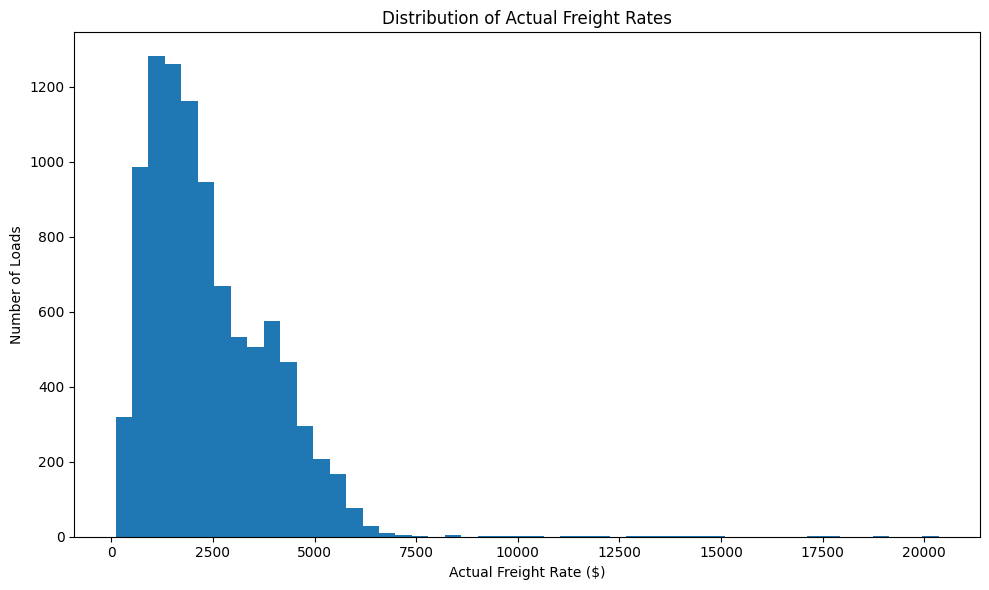

In [ ]:
# ============================================================
# VISUALIZATION 1 — ACTUAL FREIGHT RATE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    y_validation,
    bins=50
)

plt.xlabel("Actual Freight Rate ($)")
plt.ylabel("Number of Loads")
plt.title("Distribution of Actual Freight Rates")

plt.tight_layout()
plt.show()

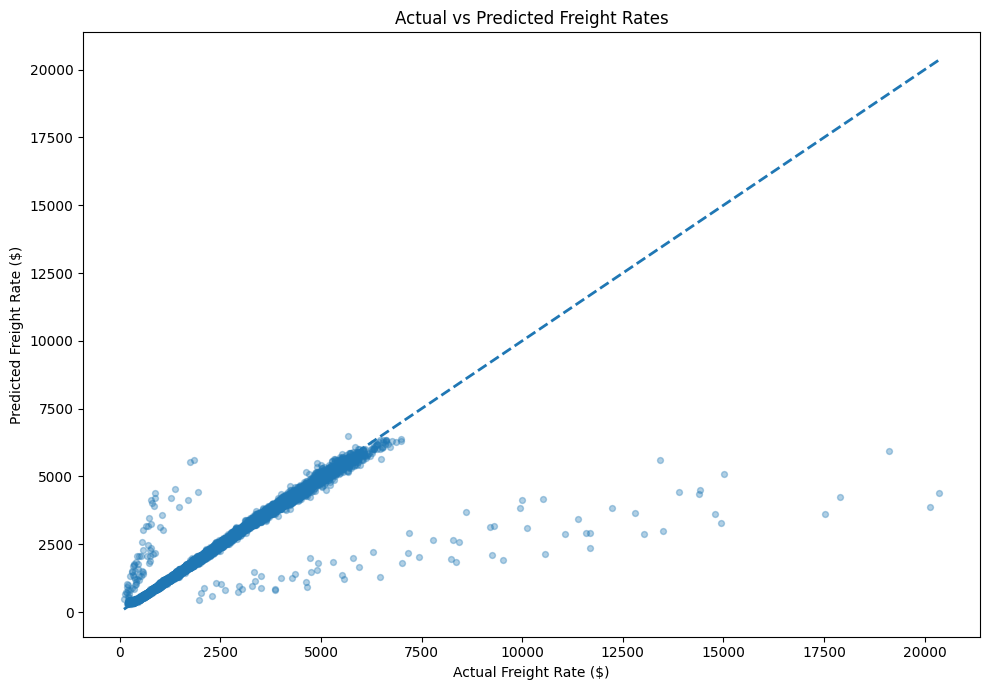

In [ ]:

# VISUALIZATION 2 — ACTUAL VS PREDICTED FREIGHT RATE


import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))

plt.scatter(
    y_validation,
    final_validation_predictions,
    alpha=0.35,
    s=18
)

# Perfect prediction line
min_value = min(y_validation.min(), final_validation_predictions.min())
max_value = max(y_validation.max(), final_validation_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    linewidth=2
)

plt.xlabel("Actual Freight Rate ($)")
plt.ylabel("Predicted Freight Rate ($)")
plt.title("Actual vs Predicted Freight Rates")

plt.tight_layout()
plt.show()

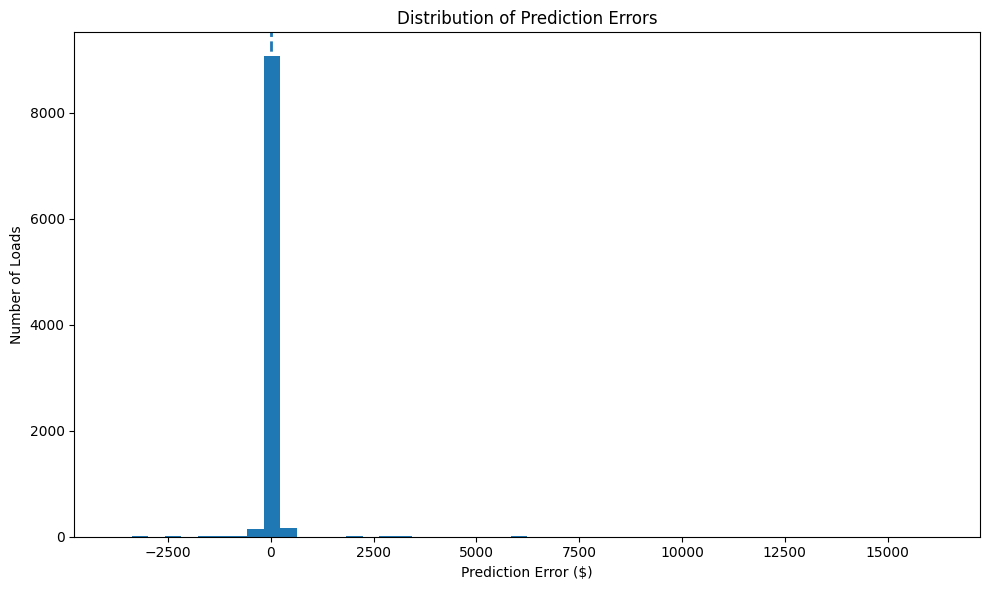

In [ ]:
# ============================================================
# VISUALIZATION 3 — RESIDUAL / ERROR DISTRIBUTION
# ============================================================

errors = (
    y_validation.values
    - final_validation_predictions
)

plt.figure(figsize=(10, 6))

plt.hist(
    errors,
    bins=50
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=2
)

plt.xlabel("Prediction Error ($)")
plt.ylabel("Number of Loads")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

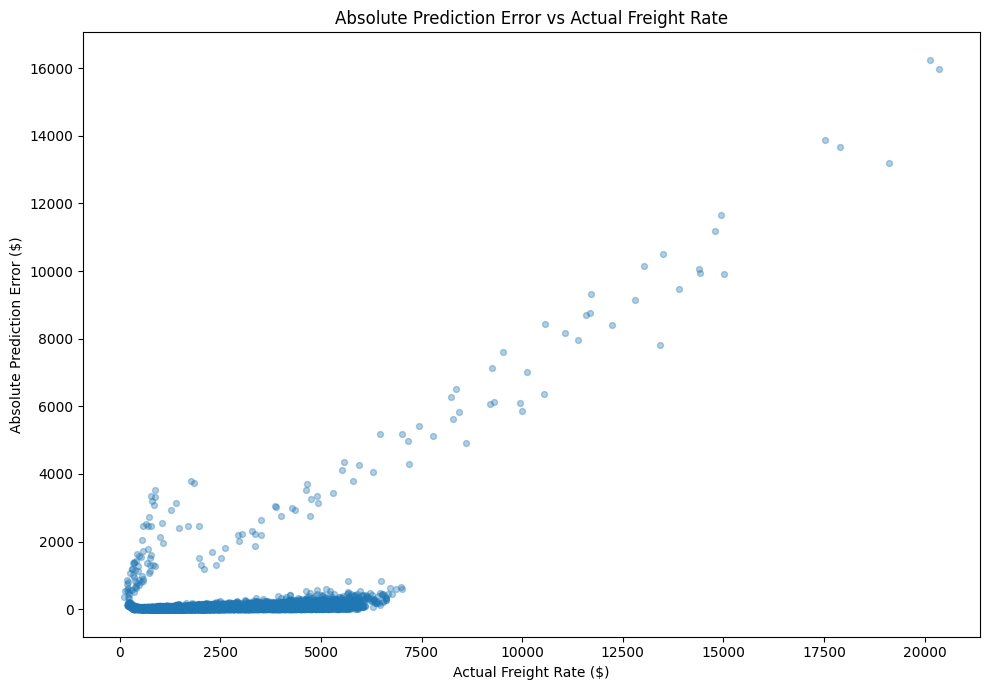

In [ ]:
# ============================================================
# VISUALIZATION 4 — ABSOLUTE ERROR VS ACTUAL RATE
# ============================================================

absolute_errors = np.abs(
    y_validation.values - final_validation_predictions
)

plt.figure(figsize=(10, 7))

plt.scatter(
    y_validation,
    absolute_errors,
    alpha=0.35,
    s=18
)

plt.xlabel("Actual Freight Rate ($)")
plt.ylabel("Absolute Prediction Error ($)")
plt.title("Absolute Prediction Error vs Actual Freight Rate")

plt.tight_layout()
plt.show()

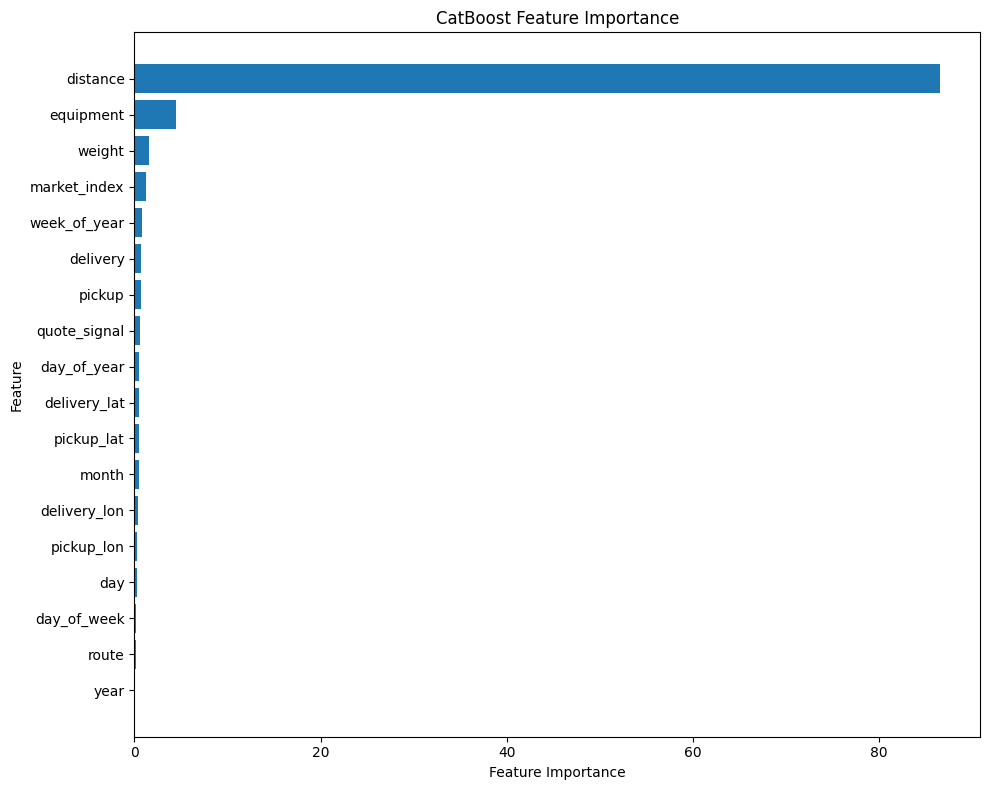

Feature importance ranking:


,feature,importance
0,distance,86.538951
1,equipment,4.459075
2,weight,1.608618
3,market_index,1.240495
4,week_of_year,0.819966
5,delivery,0.690393
6,pickup,0.665242
7,quote_signal,0.573499
8,day_of_year,0.536568
9,delivery_lat,0.533423


In [ ]:
# ============================================================
# VISUALIZATION 5 — CATBOOST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": final_candidate_model.feature_names_,
    "importance": final_candidate_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.tight_layout()
plt.show()

print("Feature importance ranking:")
display(
    feature_importance.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)
)

Monthly performance:


,month,MAE,RMSE
0,9,109.614813,615.315323
1,10,113.545664,649.041726


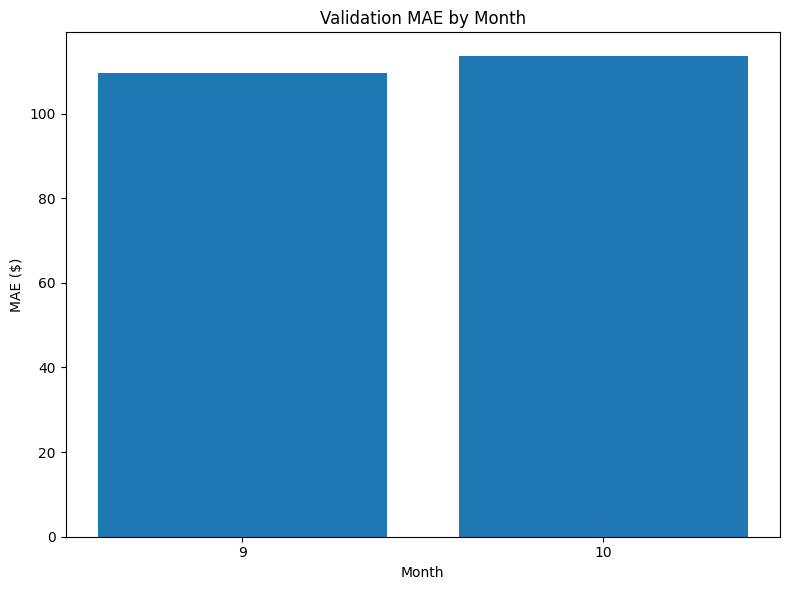

In [ ]:
# ============================================================
# VISUALIZATION 6 — MONTHLY PERFORMANCE
# ============================================================

monthly_results = pd.DataFrame({
    "month": validation_features["date"].dt.month.values,
    "actual": y_validation.values,
    "predicted": final_validation_predictions
})

monthly_summary = (
    monthly_results
    .groupby("month")
    .apply(
        lambda x: pd.Series({
            "MAE": mean_absolute_error(
                x["actual"],
                x["predicted"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    x["actual"],
                    x["predicted"]
                )
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print("Monthly performance:")
display(monthly_summary)

# Plot MAE
plt.figure(figsize=(8, 6))

plt.bar(
    monthly_summary["month"].astype(str),
    monthly_summary["MAE"]
)

plt.xlabel("Month")
plt.ylabel("MAE ($)")
plt.title("Validation MAE by Month")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL VALIDATION PREDICTIONS CSV
# ============================================================

submission = pd.DataFrame({
    "load_id": validation_clean["load_id"].values,
    "predicted_rate": final_predictions
})

submission.to_csv(
    "validation_predictions.csv",
    index=False
)

print("FINAL CSV CREATED")
print("=" * 60)
print("Filename: validation_predictions.csv")
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())

print("\nMissing values:")
print(submission.isna().sum())

print("\nDuplicate load IDs:")
print(submission["load_id"].duplicated().sum())

print("\nFirst 5 rows:")
display(submission.head())

FINAL CSV CREATED
Filename: validation_predictions.csv
Shape: (12000, 2)
Columns: ['load_id', 'predicted_rate']

Missing values:
load_id           0
predicted_rate    0
dtype: int64

Duplicate load IDs:
0

First 5 rows:


,load_id,predicted_rate
0,TE-000001,888.090414
1,TE-000002,4932.983140
2,TE-000003,5175.960736
3,TE-000004,4056.581545
4,TE-000005,1791.284625


In [ ]:
# ============================================================
# FINAL PREDICTION SANITY CHECK
# ============================================================

print("FINAL PREDICTION SANITY CHECK")
print("=" * 60)

print("Number of predictions:", len(final_predictions))
print("Minimum prediction:   ", f"${final_predictions.min():,.2f}")
print("Maximum prediction:   ", f"${final_predictions.max():,.2f}")
print("Mean prediction:      ", f"${final_predictions.mean():,.2f}")
print("Median prediction:    ", f"${np.median(final_predictions):,.2f}")

print("\nNegative predictions:")
print((final_predictions < 0).sum())

print("\nMissing predictions:")
print(np.isnan(final_predictions).sum())

FINAL PREDICTION SANITY CHECK
Number of predictions: 12000
Minimum prediction:    $270.72
Maximum prediction:    $6,906.71
Mean prediction:       $2,354.33
Median prediction:     $2,030.67

Negative predictions:
0

Missing predictions:
0


In [ ]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "Original CatBoost",
        "Log-target CatBoost",
        "Engineered CatBoost"
    ],
    "MAE": [
        111.62,
        114.52,
        119.18
    ],
    "RMSE": [
        632.73,
        635.84,
        633.45
    ],
    "R2": [
        0.8281,
        0.8264,
        0.8277
    ]
})

display(model_comparison)

,Model,MAE,RMSE,R2
0,Original CatBoost,111.62,632.73,0.8281
1,Log-target CatBoost,114.52,635.84,0.8264
2,Engineered CatBoost,119.18,633.45,0.8277


In [ ]:
# ============================================================
# FINAL MODEL METRICS
# ============================================================

print("FINAL SELECTED MODEL")
print("=" * 60)
print("Model: CatBoostRegressor")
print("Features: 18 original features")
print("Training rows: 38,477")
print("Validation rows: 9,523")
print("Best validation metrics:")
print(f"MAE  : ${111.62:,.2f}")
print(f"RMSE : ${632.73:,.2f}")
print(f"R²   : {0.8281:.4f}")

FINAL SELECTED MODEL
Model: CatBoostRegressor
Features: 18 original features
Training rows: 38,477
Validation rows: 9,523
Best validation metrics:
MAE  : $111.62
RMSE : $632.73
R²   : 0.8281


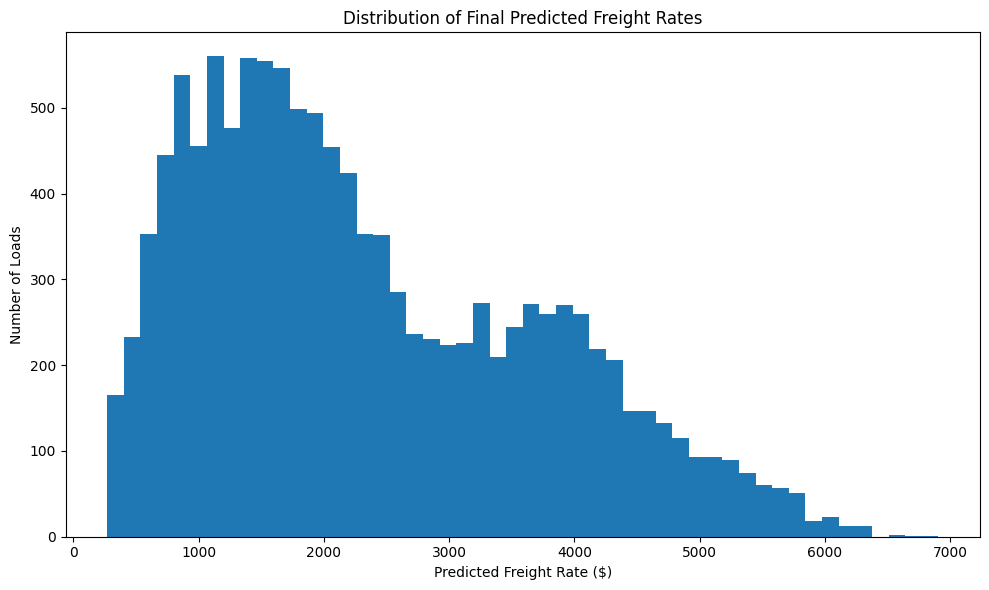

In [ ]:
# ============================================================
# VISUALIZATION 7 — FINAL PREDICTION DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    final_predictions,
    bins=50
)

plt.xlabel("Predicted Freight Rate ($)")
plt.ylabel("Number of Loads")
plt.title("Distribution of Final Predicted Freight Rates")

plt.tight_layout()
plt.show()

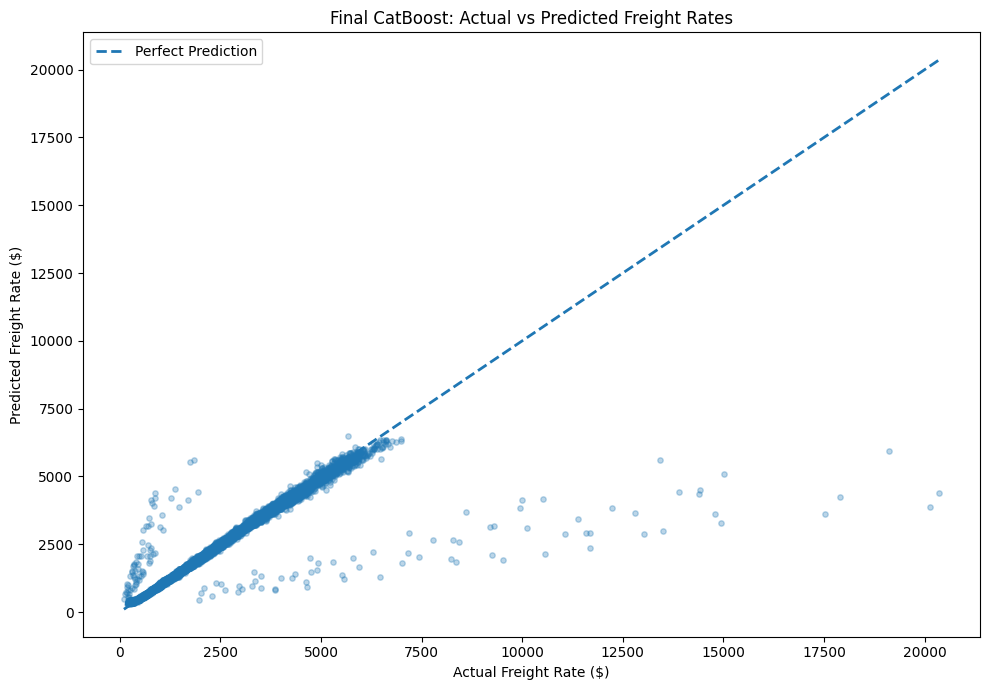

In [ ]:
# ============================================================
# VISUALIZATION 8 — FINAL VALIDATION PREDICTION PERFORMANCE
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_validation,
    final_validation_predictions,
    alpha=0.3,
    s=15
)

# Perfect prediction line
min_val = min(
    y_validation.min(),
    final_validation_predictions.min()
)

max_val = max(
    y_validation.max(),
    final_validation_predictions.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Freight Rate ($)")
plt.ylabel("Predicted Freight Rate ($)")
plt.title("Final CatBoost: Actual vs Predicted Freight Rates")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download("validation_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>